<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 7 — Filtrado de señales II: Filtros adaptativos y Transformada Wavelet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Filtrado de señales II — Filtros adaptativos (LMS) y Transformada Wavelet aplicados a EMG </font><br>
<font color="#7F000E" size=3> Laboratorio práctico · Duración: 2 horas (120 min) </font><br>
</div>

| Campo | Completar |
|---|---|
| **Nombre del estudiante** | ✍️ Jairo Villalobos Vargas, Wilber Mauricio Zenteno Castilla, Mateo Torres Ricalde, Miguel Angel Tello Ocaña |
| **Fecha** | ✍️ 2-10-2026 |

---

> **Enfoque del laboratorio:** *"Primero observamos la señal, luego la contaminamos, analizamos cómo se degrada, aplicamos diferentes técnicas de filtrado y finalmente evaluamos qué ocurrió con la señal."*

## 🎯 Resultados de aprendizaje

Al finalizar el laboratorio, serás capaz de:

1. Identificar una señal EMG en datos adquiridos mediante **BITalino (r)evolution / OpenSignals**.
2. Diferenciar **señal fisiológica**, **interferencia** y **ruido**.
3. Generar artificialmente señales contaminadas de forma controlada.
4. Aplicar filtros digitales (pasa-banda y notch).
5. Comparar métodos de filtrado con criterios visuales y cuantitativos.
6. Comprender conceptualmente el **filtrado adaptativo** (algoritmo LMS).
7. Comprender para qué sirve la **Transformada Wavelet**.
8. Evaluar la recuperación de una señal EMG.
9. Comunicar los resultados mediante una **infografía**.

## ⏱️ Agenda de la sesión (120 min)

| Bloque | Contenido | Duración | Minutos |
|---|---|---:|---:|
| 1 | Introducción y exploración de datos | 15 min | 0 – 15 |
| 2 | Señal EMG original | 15 min | 15 – 30 |
| 3 | Contaminación artificial + análisis en frecuencia | 20 min | 30 – 50 |
| 4 | Aplicación de filtros convencionales + métricas | 25 min | 50 – 75 |
| 5 | Filtros adaptativos y Wavelet | 20 min | 75 – 95 |
| 6 | Comparación e interpretación | 10 min | 95 – 105 |
| 7 | Retroalimentación, síntesis e infografía | 15 min | 105 – 120 |

> 🔁 **Los últimos 30 minutos (min 90 – 120)** se dedican a **revisión, discusión y retroalimentación**: cierre de la discusión Wavelet, comparación global (Bloque 6), preguntas, síntesis *SUMARIZE* e infografía (Bloque 7). En este tramo **no se introducen conceptos nuevos**.

**Patrón de trabajo en cada sección:**

```text
CONCEPTO → EXPLICACIÓN BREVE → CÓDIGO → GRÁFICA → INTERPRETACIÓN → PREGUNTA AL ESTUDIANTE
```

---
# 🟦 BLOQUE 1 — Introducción y exploración de datos *(15 min)*

## 1.1 Librerías

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Operaciones numéricas con vectores: eje temporal, senoides, ruido, FFT. |
| `pandas` | Leer el archivo de texto como tabla y explorar columnas/estadísticas. |
| `matplotlib` | Graficar señales en tiempo y frecuencia. |
| `scipy.signal` | Diseñar y aplicar filtros digitales (`butter`, `iirnotch`, `filtfilt`, `freqz`). |
| `pywt` (PyWavelets) | Transformada Wavelet discreta: descomposición y *denoising*. |

In [42]:
# Si trabajas en Google Colab y PyWavelets no está instalado, se instala solo en la siguiente celda.
import os
import re #NUEVO
import glob #NUEVO
import json
import sys #NUEVO
import subprocess #NUEVO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
#Se agregan más librerías porque trabajamos con varios archivos, ya no solo uno

try:
    import pywt
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "PyWavelets"], check=True)
    import pywt

# Estilo de gráficos uniforme para todo el laboratorio
plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
    "font.size": 11,
})

# Semilla: garantiza que el ruido "aleatorio" sea el mismo en cada ejecución (reproducibilidad)
rng = np.random.default_rng(seed=42)

print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| PyWavelets:", pywt.__version__)

NumPy: 2.1.3 | Pandas: 2.2.3 | PyWavelets: 1.8.0


## 1.2 Los archivos `opensignals_*.txt` (formato OpenSignals)

Un archivo exportado por **OpenSignals** tiene dos partes:

1. **Cabecera**: líneas que comienzan con `#`. Una de ellas contiene un diccionario JSON con los metadatos de adquisición (frecuencia de muestreo, resolución, nombres de columnas, etc.).
2. **Datos**: una fila por muestra, con columnas separadas por tabulaciones.

| Columna | Significado | ¿Es EMG? |
|---|---|---|
| `nSeq` | Contador de secuencia de paquetes | ❌ |
| `I1`, `I2` | Entradas digitales | ❌ |
| `O1`, `O2` | Salidas digitales | ❌ |
| `A1` | Canal analógico con el sensor EMG (`EMGBITREV`) | ✅ |

> **Adaptación para las señales EMG que se registraron en el tercer laboratorio:** la guía original trabaja con un ECG en el canal `A2`. Aquí trabajamos con 10 registros de EMG adquiridos con BITalino (r)evolution en el canal `A1` (el nombre del canal se lee de la cabecera, no se supone).

### Los 10 registros

En el laboratorio 3 se evaluaron **4 músculos** en **3 fases** (reposo, movimiento leve y fuerza máxima); en el bíceps braquial se hizo una sola adquisición.

| Archivo | Músculo | Fase |
|---|---|---|
| `01` | Bíceps braquial | Sesión única (contiene reposo → leve → máxima, ver Bloque 2) |
| `02`, `03`, `04` | Abductor corto del pulgar | Reposo, leve, fuerza máxima |
| `05`, `06`, `07` | Trapecio superior | Reposo, leve, fuerza máxima |
| `08`, `09`, `10` | Cigomático mayor | Reposo, leve, fuerza máxima |

Primero aseguramos que los archivos estén disponibles (en Colab se pueden subir desde la computadora).

In [43]:
CARPETA = "/content/EMG_Señales"
ARCHIVO_PRINCIPAL = 1      # bíceps (3 fases en un archivo)

MAPA = {
     1: ("Bíceps braquial", "Sesión única"),
     2: ("Abductor corto del pulgar", "Reposo"),
     3: ("Abductor corto del pulgar", "Leve"),
     4: ("Abductor corto del pulgar", "Fuerza máxima"),
     5: ("Trapecio superior", "Reposo"),
     6: ("Trapecio superior", "Leve"),
     7: ("Trapecio superior", "Fuerza máxima"),
     8: ("Cigomático mayor", "Reposo"),
     9: ("Cigomático mayor", "Leve"),
     10: ("Cigomático mayor", "Fuerza máxima"),
}

def buscar_archivos(carpeta):
    """Devuelve {número: ruta} para archivos tipo '07_opensignals_....txt'."""
    encontrados = {}
    for ruta in glob.glob(os.path.join(carpeta, "*opensignals*.txt")):
        m = re.search(r"(?:^|[-_ ])(\d{2})_opensignals", os.path.basename(ruta), flags=re.I)
        if m:
            encontrados[int(m.group(1))] = ruta
    return dict(sorted(encontrados.items()))
archivos = buscar_archivos(CARPETA)

if len(archivos) < len(MAPA):
    try:
        from google.colab import files   # Solo existe en Google Colab
        print("Selecciona los 10 archivos .txt desde tu computadora...")
        os.makedirs(CARPETA, exist_ok=True)
        for nombre, datos in files.upload().items():
            with open(os.path.join(CARPETA, nombre), "wb") as f:
                f.write(datos)
        archivos = buscar_archivos(CARPETA)
    except ImportError:
        print(f"⚠️ No se encontraron los 10 archivos en '{CARPETA}'. Colócalos ahí.")

print("¿Archivos disponibles?:", len(archivos), "de", len(MAPA))
musculo, fase = MAPA[ARCHIVO_PRINCIPAL]

¿Archivos disponibles?: 10 de 10


### Leer la cabecera

Leemos solo las líneas iniciales que empiezan con `#` y extraemos los metadatos **directamente del archivo** (no los suponemos).

In [44]:
# 1) Guardar las líneas de cabecera (empiezan con '#')
RUTA_ARCHIVO = archivos[ARCHIVO_PRINCIPAL]
lineas_cabecera = []
with open(RUTA_ARCHIVO, "r", encoding="utf-8", errors="ignore") as archivo:
    for linea in archivo:
        if linea.startswith("#"):
            lineas_cabecera.append(linea.strip())
        else:
            break  # termina la cabecera, empiezan los datos

print("Cabecera del archivo:\n")
for linea in lineas_cabecera:
    print(linea[:300] + ("..." if len(linea) > 300 else ""))

# 2) Buscar la línea JSON con los metadatos del dispositivo
metadatos = {}
for linea in lineas_cabecera:
    contenido = linea.lstrip("#").strip()
    if contenido.startswith("{"):
        try:
            diccionario = json.loads(contenido)
            metadatos = list(diccionario.values())[0]   # primer dispositivo (identificado por su MAC)
        except json.JSONDecodeError:
            print("No se pudo interpretar el JSON de la cabecera.")

# 3) Extraer los parámetros relevantes (con valores por defecto si faltaran)
Fs = int(metadatos.get("sampling rate", 1000))
columnas = metadatos.get("column", ["nSeq", "I1", "I2", "O1", "O2", "A1"])
CANAL = metadatos.get("label", ["A1"])[0]          # canal analógico activo (aquí: A1)
sensor = metadatos.get("sensor", ["?"])[0]
resoluciones = metadatos.get("resolution", [])
resolucion_canal = resoluciones[columnas.index(CANAL)] if len(resoluciones) == len(columnas) else 10

print("\nFrecuencia de muestreo (Fs):", Fs, "Hz")
print("Columnas:", columnas)
print(f"Canal activo: {CANAL} | Sensor: {sensor} | Resolución: {resolucion_canal} bits")

Cabecera del archivo:

# OpenSignals Text File Format. Version 1
# {"0C:43:14:24:7F:C7": {"position": 0, "device": "bitalino_rev", "device name": "0C:43:14:24:7F:C7", "device connection": "BTH0C:43:14:24:7F:C7", "sampling rate": 1000, "resolution": [4, 1, 1, 1, 1, 10], "firmware version": 1282, "comments": "", "keywords": "", "mode": 0, "sync interval": 2, "date"...
# EndOfHeader

Frecuencia de muestreo (Fs): 1000 Hz
Columnas: ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A1']
Canal activo: A1 | Sensor: EMGBITREV | Resolución: 10 bits


### Leer los datos

In [45]:
# comment="#" ignora la cabecera; sep=r"\s+" admite tabulaciones (y tabulaciones finales)
datos = pd.read_csv(RUTA_ARCHIVO, sep=r"\s+", comment="#", header=None)
datos = datos.iloc[:, :len(columnas)]   # nos quedamos solo con las columnas declaradas
datos.columns = columnas

numero_muestras = len(datos)
Ts = 1 / Fs                              # periodo de muestreo
duracion_total = numero_muestras / Fs

print(f"Número de muestras : {numero_muestras}")
print(f"Frecuencia muestreo: {Fs} Hz")
print(f"Periodo de muestreo: {Ts*1000:.1f} ms")
print(f"Duración total     : {duracion_total:.2f} s")
print(f"Columnas           : {list(datos.columns)}")
datos.head(10)

Número de muestras : 51000
Frecuencia muestreo: 1000 Hz
Periodo de muestreo: 1.0 ms
Duración total     : 51.00 s
Columnas           : ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A1']


,nSeq,I1,I2,O1,O2,A1
0,0,0,0,0,0,507
1,1,0,0,0,0,506
2,2,0,0,0,0,510
3,3,0,0,0,0,510
4,4,0,0,0,0,515
5,5,0,0,0,0,516
6,6,0,0,0,0,511
7,7,0,0,0,0,509
8,8,0,0,0,0,512
9,9,0,0,0,0,514


In [46]:
# Estadísticas básicas de todas las columnas
datos.describe().T

,count,mean,std,min,25%,50%,75%,max
nSeq,51000.0,7.499373,4.609817,0.0,3.0,7.0,11.0,15.0
I1,51000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
I2,51000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
O1,51000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
O2,51000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
A1,51000.0,511.992118,60.134070,0.0,506.0,512.0,520.0,1022.0


### ¿Por qué **no** usar `nSeq` como eje temporal?

`nSeq` es un **contador de paquetes** que se reinicia periódicamente (en BITalino es un contador de 4 bits: 0, 1, …, 15, 0, 1, …). Sirve para **detectar muestras perdidas** durante la transmisión, pero **no** es el tiempo absoluto. El eje temporal correcto se construye a partir del índice de muestra y la frecuencia de muestreo:

$$t[n] = \frac{n}{F_s}$$

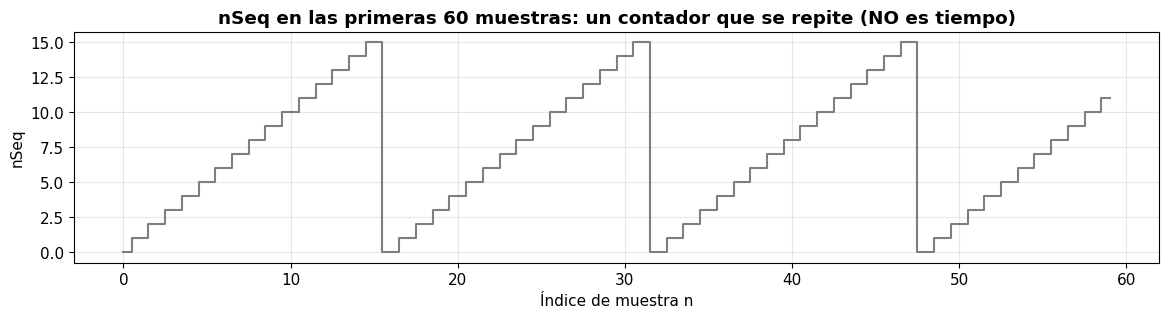

El contador va de 0 a 15.
Muestras con salto distinto de 1 (posibles pérdidas): 0


In [47]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.step(np.arange(60), datos["nSeq"].values[:60], where="mid", color="tab:gray")
ax.set_title("nSeq en las primeras 60 muestras: un contador que se repite (NO es tiempo)")
ax.set_xlabel("Índice de muestra n"); ax.set_ylabel("nSeq")
plt.show()

# Verificación de paquetes perdidos: el salto esperado entre muestras consecutivas es 1 (módulo del contador)
modulo = int(datos["nSeq"].max()) + 1
saltos = np.diff(datos["nSeq"].values) % modulo
print(f"El contador va de 0 a {modulo-1}.")
print("Muestras con salto distinto de 1 (posibles pérdidas):", int(np.sum(saltos != 1)))

### ❓ Pregunta al estudiante (Bloque 1)
Según la cabecera, ¿cuántos niveles distintos puede tomar el canal `A1` (el canal activo)? (Pista: $2^{\text{bits}}$). ¿Por qué es útil verificar `nSeq` antes de analizar la señal?

✍️ **Respuesta:**

El canal `A1` tiene 10 bits, así que puede tomar $2^{10} = 1024$ niveles (valores ADC de 0 a 1023). Respondiendo la otra pregunta, verificar `nSeq` sirve para detectar paquetes perdidos en la transmisión Bluetooth: si el contador salta, faltan muestras y el eje $t = n/F_s$ dejaría de ser válido. En este registro el contador va de 0 a 15 y hay 0 saltos anómalos, por lo que el muestreo fue continuo.

---
# 🟦 BLOQUE 2 — Señal EMG original *(15 min)*

## 2.1 Conceptos mínimos

- **Amplitud**: magnitud de la señal (aquí, en mV).
- **Tiempo**: eje horizontal construido con $t = n/F_s$.
- **Frecuencia de muestreo** $F_s$: muestras por segundo (1000 Hz → 1000 muestras/s).
- **Periodo de muestreo** $T_s = 1/F_s$: tiempo entre muestras (1 ms).
- **Morfología EMG**: a diferencia del ECG, **no tiene una forma repetitiva** (no hay QRS). El EMG es la suma de muchos potenciales de acción de unidades motoras: se ve como una señal **aleatoria de banda ancha** cuya **amplitud (envolvente) crece con la fuerza** de la contracción.
- **Ruido**: componente aleatoria, no deseada, generalmente de banda ancha.
- **Interferencia**: componente no deseada con origen y estructura identificables (p. ej., la red eléctrica a una frecuencia fija).

## 2.2 Extraer `A1` y convertir a milivoltios

El canal activo contiene valores del conversor analógico-digital (ADC). Para expresarlos en mV usamos la función de transferencia del sensor EMG de BITalino (hoja de datos del fabricante):

$$EMG_{mV} = \left(\frac{ADC}{2^{n}} - \frac{1}{2}\right)\cdot\frac{V_{CC}}{G_{EMG}}\cdot 1000, \qquad V_{CC}=3.3\,\text{V},\; G_{EMG}=1009$$

> Si tu sensor fuera distinto, puedes trabajar directamente en unidades ADC: los filtros funcionan igual.

In [48]:
VCC = 3.3       # voltaje de operación (V)
G_EMG = 1009    # ganancia del sensor EMG de BITalino (r)evolution

emg_adc = datos[CANAL].to_numpy(dtype=float)
emg_mV = ((emg_adc / 2**resolucion_canal) - 0.5) * VCC / G_EMG * 1000

# Señal de referencia del laboratorio: EMG REAL centrado en cero (restamos la media)
emg_original = emg_mV - np.mean(emg_mV)

# Eje temporal correcto
t = np.arange(len(emg_original)) / Fs

# Saturación del conversor (valores 0 o 2^n - 1): indica que la señal "se recortó"
saturacion = np.mean((emg_adc <= 0) | (emg_adc >= 2**resolucion_canal - 1)) * 100

print(f"Amplitud mínima: {emg_original.min():.3f} mV | máxima: {emg_original.max():.3f} mV")
print(f"Desviación estándar (RMS): {np.std(emg_original):.3f} mV")
print(f"Muestras saturadas: {saturacion:.2f} %")

Amplitud mínima: -1.635 mV | máxima: 1.629 mV
Desviación estándar (RMS): 0.192 mV
Muestras saturadas: 0.12 %


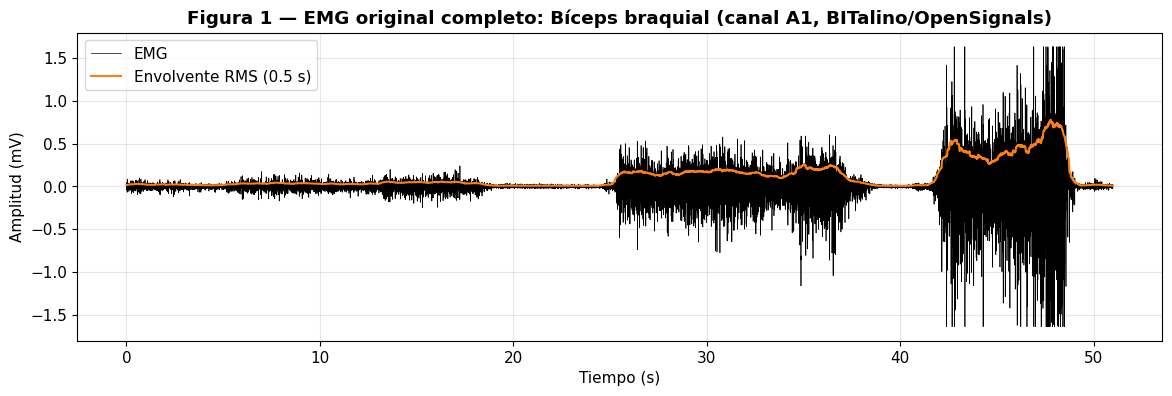

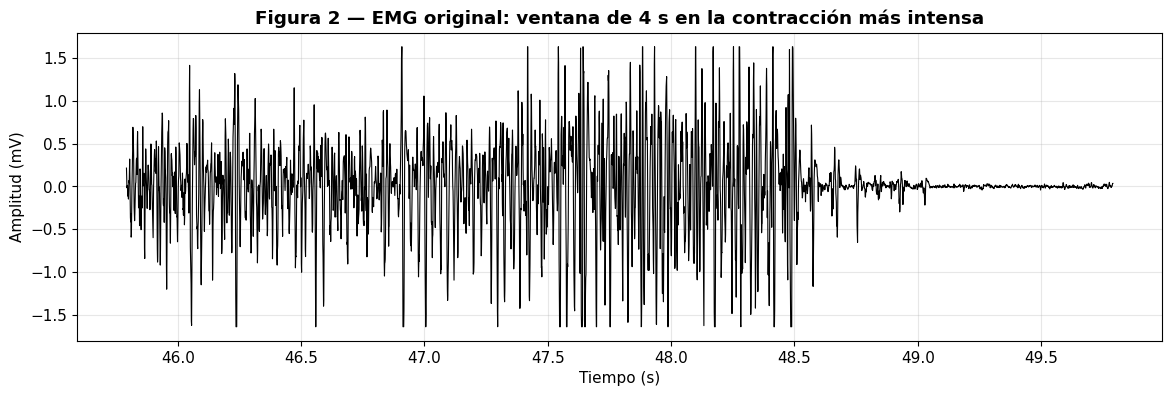

In [49]:
# Ventana de observación para todos los acercamientos: 4 s centrados en la contracción más intensa
DURACION_ZOOM = 4.0                                    # segundos
n_env = int(0.5 * Fs)                                  # envolvente RMS con ventana de 0.5 s
envolvente = np.sqrt(np.convolve(emg_original ** 2, np.ones(n_env) / n_env, mode="same"))
t_pico = t[np.argmax(envolvente)]
T_INICIO_ZOOM = float(np.clip(t_pico - DURACION_ZOOM / 2, 0, max(duracion_total - DURACION_ZOOM, 0)))
zoom = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + DURACION_ZOOM)

# Figura 1: EMG completo (con su envolvente)
plt.figure(figsize=(14, 4))
plt.plot(t, emg_original, color="black", lw=0.5, label="EMG")
plt.plot(t, envolvente, color="tab:orange", lw=1.5, label="Envolvente RMS (0.5 s)")
plt.title(f"Figura 1 — EMG original completo: {musculo} (canal {CANAL}, BITalino/OpenSignals)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud (mV)"); plt.legend(loc="upper left")
plt.show()

# Figura 2: ventana corta
plt.figure(figsize=(14, 4))
plt.plot(t[zoom], emg_original[zoom], color="black", lw=0.8)
plt.title(f"Figura 2 — EMG original: ventana de {DURACION_ZOOM:.0f} s en la contracción más intensa")
plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud (mV)")
plt.show()

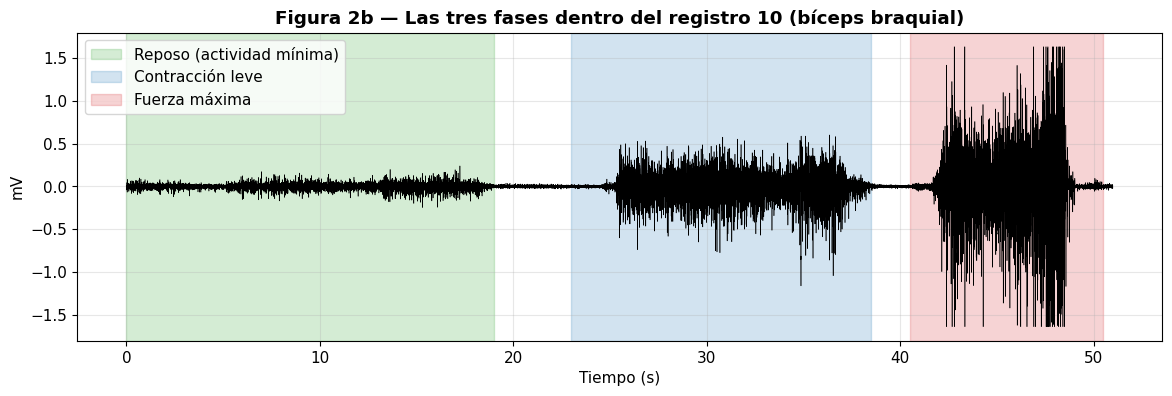

In [50]:
# Si el archivo principal es el 01 (bíceps, sesión única), separamos sus 3 episodios usando la envolvente.
# Los límites, en segundos, se eligieron mirando la Figura 1: hay pausas casi planas entre una contracción y otra.
FASES_ARCHIVO_1 = {
    "Reposo (actividad mínima)": (0, 19),
    "Contracción leve":          (23, 38.5),
    "Fuerza máxima":             (40.5, 50.5),
}

if ARCHIVO_PRINCIPAL == 1:
    colores_fase = ["tab:green", "tab:blue", "tab:red"]
    plt.figure(figsize=(14, 4))
    plt.plot(t, emg_original, color="black", lw=0.4)
    filas = []
    for (nombre, (a, b)), col in zip(FASES_ARCHIVO_1.items(), colores_fase):
        plt.axvspan(a, b, color=col, alpha=0.2, label=nombre)
        seg = emg_original[(t >= a) & (t < b)]
        filas.append({"Fase": nombre, "Inicio (s)": a, "Fin (s)": b, "RMS (mV)": np.sqrt(np.mean(seg ** 2))})
    plt.title("Figura 2b — Las tres fases dentro del registro 01 (bíceps braquial)")
    plt.xlabel("Tiempo (s)"); plt.ylabel("mV"); plt.legend(loc="upper left")
    plt.show()

### 🔎 Interpretación
- En la **Figura 1** se observa la señal completa y su envolvente. Los "bultos" son las contracciones y los tramos casi planos son pausas (músculo relajado). Se puede deducir, por lo pedido en el laboratorio 3, que las primeras variaciones antes de la primera pausa representan el músculo relajado. Tras la primera pausa, la siguiente señal hace alucion a un musculo levemente contraído; finalmente, la última señal (la más caótica) representa la fase en la que el músculo bíceps braquial hace una fuerza máxima. Esto se observa mejor en la **Figura 2b**
- En la **Figura 2** el EMG parece ruido de banda ancha: no hay ondas repetitivas como las P, QRS y T del ECG. La información está en la amplitud y en el contenido en frecuencia, no en la forma de onda.
- Aunque esta señal es real, ya trae consigo cierta cantidad de ruido propio de la adquisición (por ejemplo, algo de 60 Hz). No es una señal "perfecta".

### ❓ Pregunta al estudiante (Bloque 2)
A partir de la Figura 2, estima la frecuencia cardiaca (latidos por minuto) contando los complejos QRS en la venta

✍️ **Respuesta:**

Se está trabajando con una señal EMG, por lo que no se puede responder esta pregunta.

---
# 🟦 BLOQUE 3 — Contaminación artificial de la señal *(20 min)*

## 3.1 ¿Por qué contaminar artificialmente?

Para **evaluar un filtro necesitamos saber cuál es la "respuesta correcta"**. Si contaminamos nosotros mismos la señal con componentes **conocidas**, podemos comparar la señal filtrada con la original y medir qué tan bien se recuperó.

$$EMG_{contaminado} = EMG_{original} + \text{interferencia}_1 + \text{interferencia}_2 + \text{ruido gaussiano}$$

> ⚠️ **Importante:** esta es una **contaminación artificial y controlada con fines didácticos**. Las frecuencias elegidas **no** representan todas las fuentes reales de ruido de un EMG (en la práctica también hay artefactos de movimiento de cables y electrodos, deriva de línea de base, señal cardiaca (ECG) que se cuela, mal contacto de electrodos, activación de otros músculos vecinos, etc.).

**Elección de frecuencias:** en Perú la red eléctrica opera a **60 Hz**, por eso usamos $f_1 = 60$ Hz y su segundo armónico $f_2 = 120$ Hz. Si quieres reproducir el caso europeo, cambia a 50 y 100 Hz. **Todos los parámetros son modificables.**

> 💡 **Diferencia clave con el ECG:** el EMG ocupa aproximadamente **20 – 450 Hz**, así que 60 Hz y 120 Hz caen **dentro de la banda útil de la señal**. Un pasa-banda no podrá separarlas; se necesitará un notch o un filtro adaptativo.

In [51]:
# =================== PARÁMETROS MODIFICABLES ===================
f1 = 60        # Hz — interferencia 1 (red eléctrica en Perú)
f2 = 120       # Hz — interferencia 2 (armónico de la red)

escala = np.std(emg_original)   # referencia de amplitud de la propia señal
amplitud_1 = 1.0 * escala       # amplitud de la interferencia 1 (mV)
amplitud_2 = 0.6 * escala       # amplitud de la interferencia 2 (mV)
sigma_ruido = 0.3 * escala      # desviación estándar del ruido gaussiano (mV)
# ===============================================================

# Fases aleatorias (pero reproducibles): las interferencias reales no empiezan en fase cero
fase_1, fase_2 = rng.uniform(0, 2 * np.pi, size=2)

ruido_senoidal_1 = amplitud_1 * np.sin(2 * np.pi * f1 * t + fase_1)
ruido_senoidal_2 = amplitud_2 * np.sin(2 * np.pi * f2 * t + fase_2)
ruido_gaussiano  = rng.normal(0, sigma_ruido, size=len(t))

emg_contaminado = (
    emg_original
    + ruido_senoidal_1
    + ruido_senoidal_2
    + ruido_gaussiano
)

print(f"Interferencia 1: {f1} Hz, amplitud {amplitud_1:.3f} mV")
print(f"Interferencia 2: {f2} Hz, amplitud {amplitud_2:.3f} mV")
print(f"Ruido gaussiano: sigma = {sigma_ruido:.3f} mV")

Interferencia 1: 60 Hz, amplitud 0.192 mV
Interferencia 2: 120 Hz, amplitud 0.115 mV
Ruido gaussiano: sigma = 0.058 mV


## 3.2 Visualización de cada componente

Usamos una ventana de **1 segundo** para que las oscilaciones sean distinguibles.

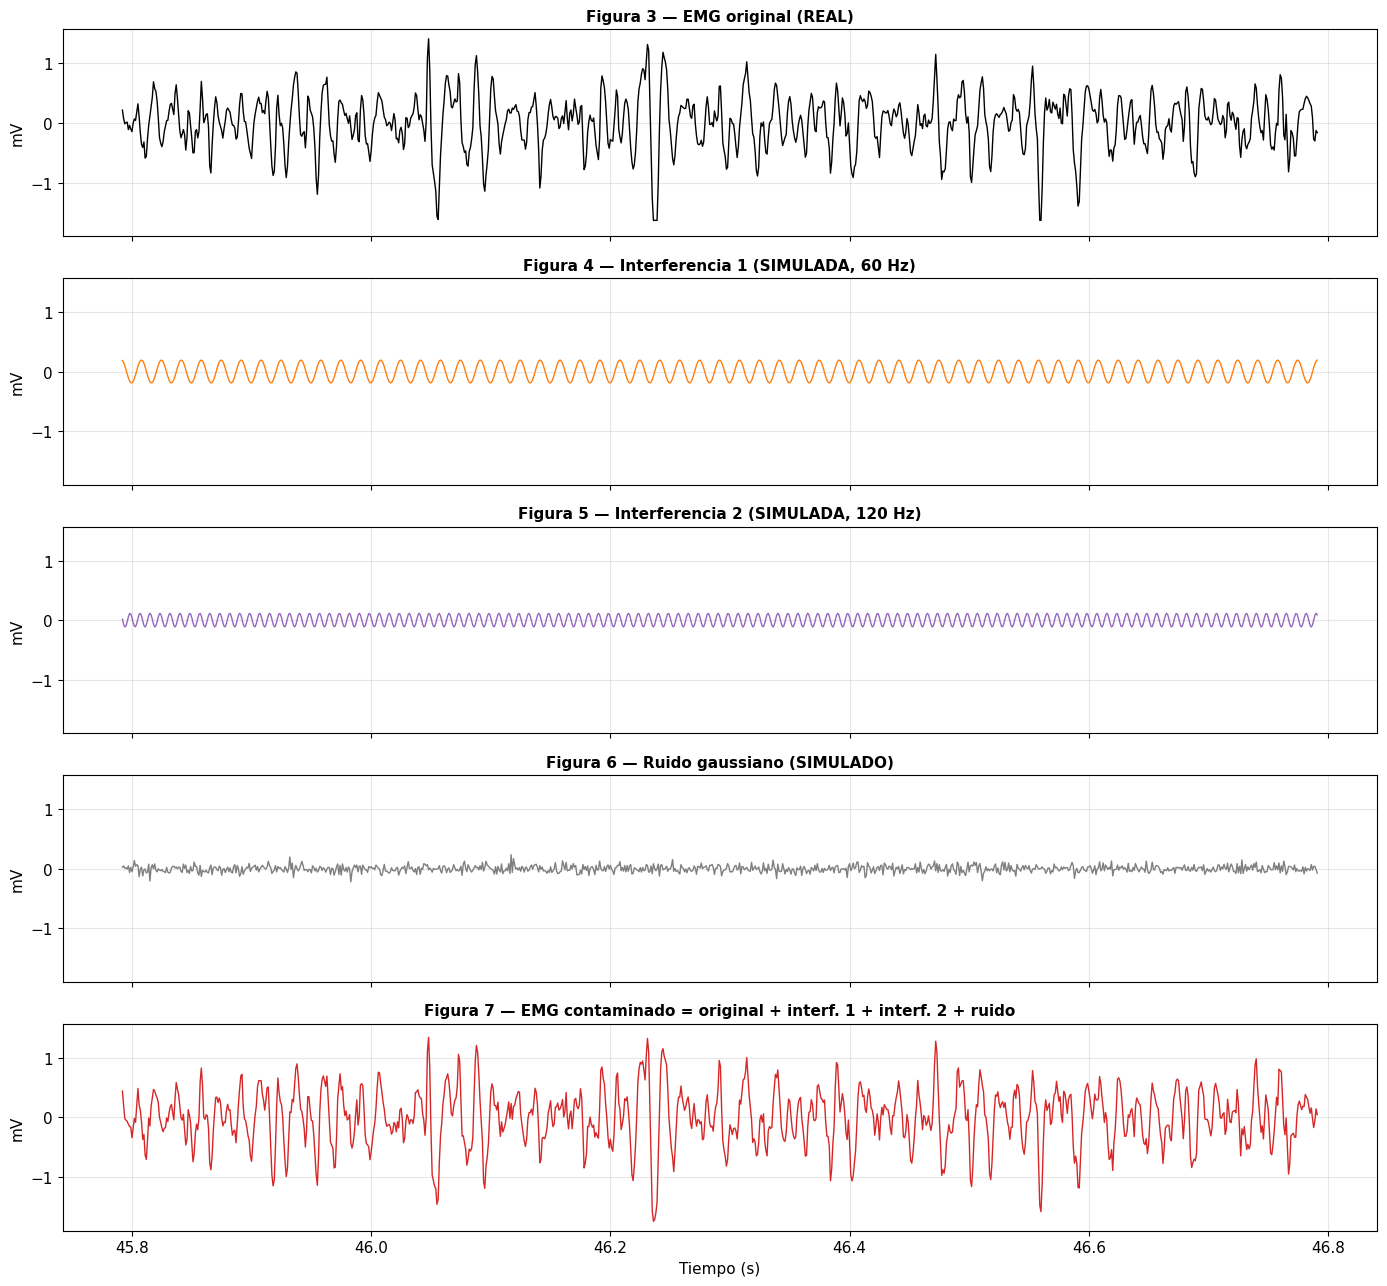

In [52]:
ventana_1s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 1.0)

componentes = [
    ("Figura 3 — EMG original (REAL)", emg_original, "black"),
    (f"Figura 4 — Interferencia 1 (SIMULADA, {f1} Hz)", ruido_senoidal_1, "tab:orange"),
    (f"Figura 5 — Interferencia 2 (SIMULADA, {f2} Hz)", ruido_senoidal_2, "tab:purple"),
    ("Figura 6 — Ruido gaussiano (SIMULADO)", ruido_gaussiano, "tab:gray"),
    ("Figura 7 — EMG contaminado = original + interf. 1 + interf. 2 + ruido", emg_contaminado, "tab:red"),
]

fig, ejes = plt.subplots(len(componentes), 1, figsize=(14, 13), sharex=True, sharey=True)
for eje, (titulo, senal, color) in zip(ejes, componentes):
    eje.plot(t[ventana_1s], senal[ventana_1s], color=color, lw=1)
    eje.set_title(titulo, fontsize=11)
    eje.set_ylabel("mV")
ejes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

```text
EMG original
        ↓
+ interferencias (f1, f2)
        ↓
+ ruido gaussiano
        ↓
EMG contaminado
```

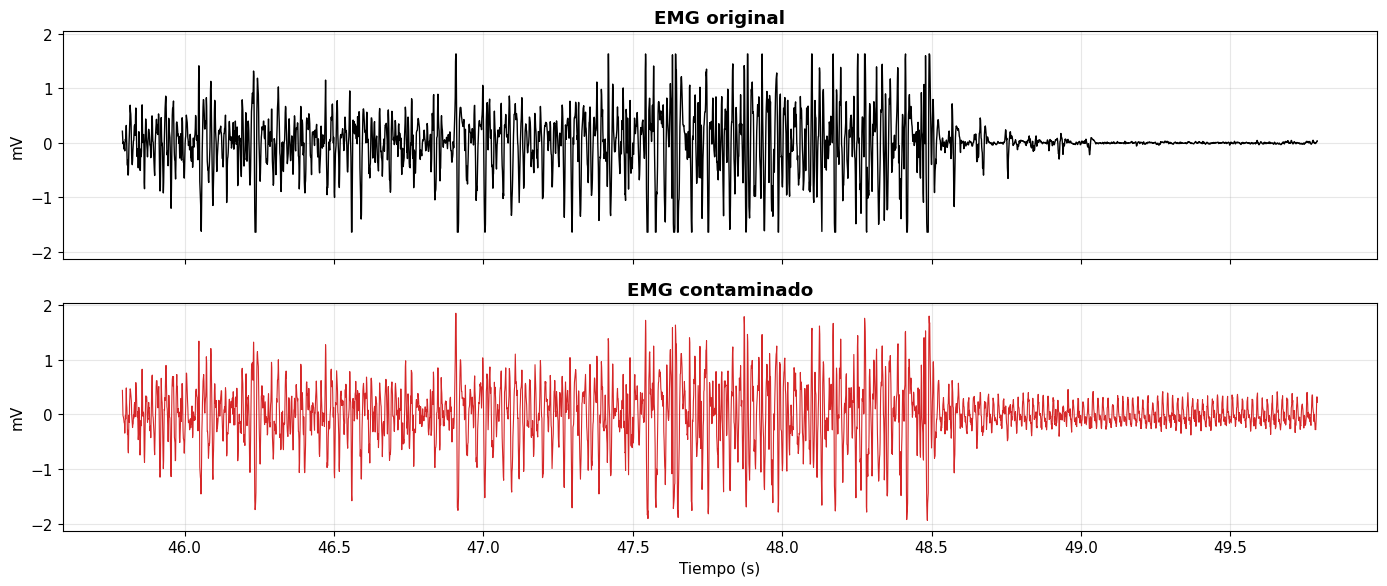

In [53]:
# Comparación directa en la ventana de 4 s
fig, ejes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
ejes[0].plot(t[zoom], emg_original[zoom], color="black", lw=1)
ejes[0].set_title("EMG original")
ejes[1].plot(t[zoom], emg_contaminado[zoom], color="tab:red", lw=0.8)
ejes[1].set_title("EMG contaminado")
for eje in ejes: eje.set_ylabel("mV")
ejes[1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

### 🔎 Observa y anota
- ¿Cambió la amplitud aparente de la señal?
- ¿Se conserva la forma de las ondas P y T?
- ¿Qué oscilaciones regulares aparecen?
- ¿Hay ruido de alta frecuencia ("grosor" del trazo)?
- ¿Es más difícil distinguir el inicio y el fin de la contracción?

✍️ **Respuesta:**

- La amplitud aparente apenas cambió durante la contracción fuerte (la señal es grande y tapa la contaminación), pero en los tramos de pausa (más debiles) el cambio más claro.
- La señal EMG no tiene estas ondas, pero en sí la envolvente de la contracción se conserva, pero en las pausas (donde el original es plano) aparece una oscilación regular de ≈ ±0.4 - 0.5 mV. Es la interferencia de 60 Hz (con el armónico de 120 Hz).
- El trazo se ve más "grueso" por el ruido gaussiano de alta frecuencia.
- Es más difícil decidir cuándo termina la contracción y detectar contracciones leves: la interferencia tiene una amplitud comparable a la del EMG débil.

## 3.3 Análisis en el dominio de la frecuencia

> Una señal puede analizarse no solamente en función del tiempo, sino también en función de sus **componentes frecuenciales**.

```text
Dominio temporal
        ↕   Transformada de Fourier (FFT)
Dominio frecuencial
```

Intuitivamente, la FFT responde: *¿cuánto de cada frecuencia contiene la señal?* Una senoide pura de frecuencia $f_0$ aparece como **un pico estrecho** en $f_0$. El ruido gaussiano, en cambio, reparte su energía en **todas** las frecuencias (fondo plano).

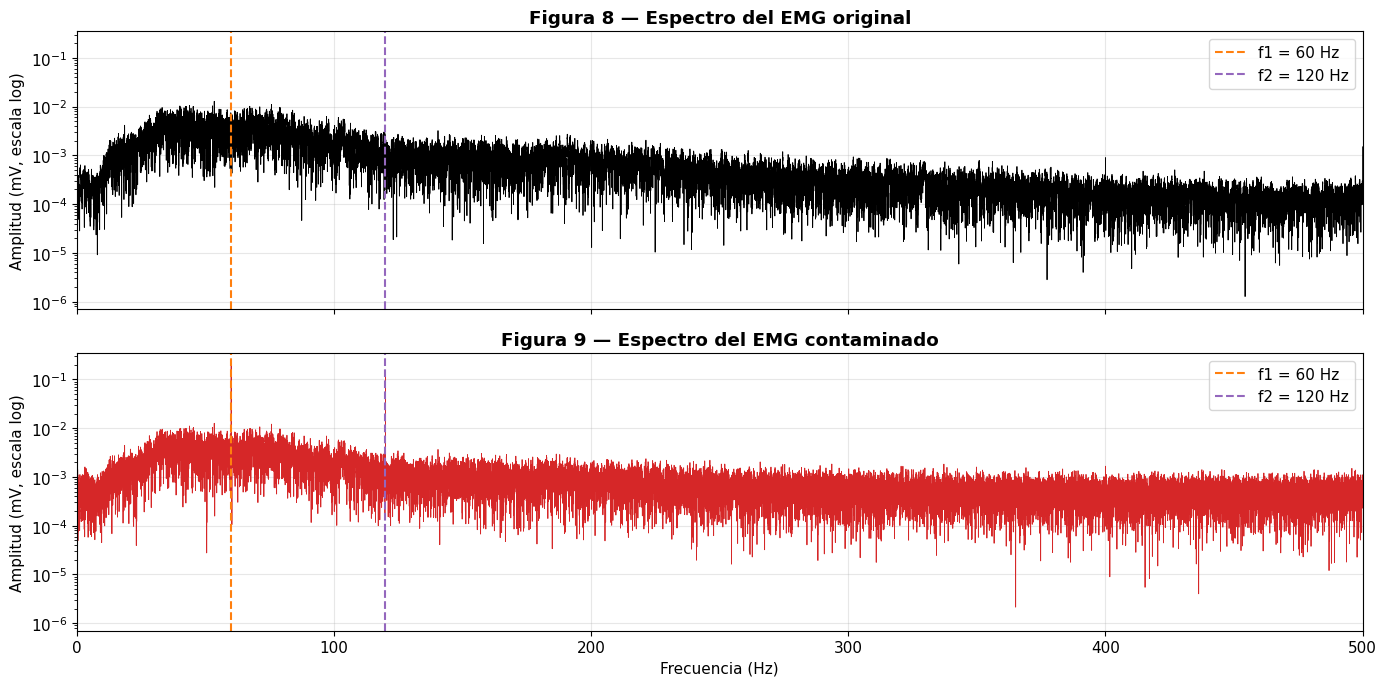

In [54]:
def espectro_amplitud(x, Fs):
    """Espectro de amplitud de un solo lado usando la FFT de NumPy."""
    N = len(x)
    X = np.fft.rfft(x - np.mean(x))
    frecuencias = np.fft.rfftfreq(N, d=1/Fs)
    amplitud = 2 * np.abs(X) / N
    return frecuencias[1:], amplitud[1:]   # omitimos 0 Hz (la media ya fue restada)

freq, amp_original = espectro_amplitud(emg_original, Fs)
_,    amp_contaminado = espectro_amplitud(emg_contaminado, Fs)

F_MAX_GRAFICO = Fs / 2
fig, ejes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, sharey=True)
ejes[0].semilogy(freq, amp_original, color="black", lw=0.6)
ejes[0].set_title("Figura 8 — Espectro del EMG original")
ejes[1].semilogy(freq, amp_contaminado, color="tab:red", lw=0.6)
ejes[1].set_title("Figura 9 — Espectro del EMG contaminado")
for eje in ejes:
    eje.axvline(f1, color="tab:orange", ls="--", label=f"f1 = {f1} Hz")
    eje.axvline(f2, color="tab:purple", ls="--", label=f"f2 = {f2} Hz")
    eje.set_ylabel("Amplitud (mV, escala log)")
    eje.legend(loc="upper right")
ejes[1].set_xlabel("Frecuencia (Hz)")
ejes[1].set_xlim(0, F_MAX_GRAFICO)
plt.tight_layout(); plt.show()

### 🔎 Interpretación
- El EMG concentra su energía entre **20 y 250 Hz** (con el máximo cerca de 50 – 150 Hz); por debajo de ~20 Hz casi no hay señal útil.
- En el espectro contaminado aparecen dos picos nítidos exactamente en $f_1$ y $f_2$: son las interferencias que nosotros introdujimos.
- El ruido gaussiano eleva el "piso" del espectro en todas las frecuencias (se nota más por encima de 250 Hz, donde el EMG ya casi no tiene energía).
- Si en el EMG original ya aparece algún pico en 60 Hz, esa sería interferencia real de la adquisición (En el registro de reposo del pulgar, el archivo 02, se ve claramente.)

### ❓ Pregunta al estudiante
¿Por qué la interferencia aparece como un pico y el ruido gaussiano como un fondo? ¿Cuál de los dos será más fácil de eliminar con un filtro?

✍️ **Respuesta:**

Una sinusoide concentra toda su energía en una sola frecuencia, por eso la FFT la muestra como un pico estrecho y alto. El ruido gaussiano reparte la misma energía entre todas las frecuencias, así que cada una recibe muy poco y se ve como un fondo plano. La **interferencia es más fácil de eliminar**: al ocupar una banda tan estrecha, un notch o un filtro adaptativo la quitan casi sin tocar el EMG. El ruido gaussiano comparte frecuencias con el EMG (20 – 450 Hz), por lo que un filtro lineal no puede quitarlo sin eliminar también señal útil.

---
# 🟦 BLOQUE 4 — Aplicación de filtros digitales *(25 min)*

## 4.1 Tipos de filtros

| Filtro | Deja pasar | Uso típico en EMG |
|---|---|---|
| **Pasa-bajas** | Frecuencias por debajo de $f_c$ | Atenuar ruido electrónico de alta frecuencia (> 450 Hz). |
| **Pasa-altas** | Frecuencias por encima de $f_c$ | Eliminar artefactos de movimiento y deriva de línea de base (< 20 Hz). |
| **Pasa-banda** | Frecuencias entre $f_{c1}$ y $f_{c2}$ | Combinar ambos: típico **20 – 450 Hz** para EMG de superficie. |
| **Notch (rechaza-banda)** | Todo excepto una banda muy estrecha | Eliminar una interferencia de frecuencia conocida (red eléctrica). |

**Herramientas de `scipy.signal`:**
- `butter`: diseña un filtro Butterworth (respuesta plana en la banda de paso).
- `iirnotch`: diseña un filtro notch centrado en una frecuencia.
- `filtfilt`: aplica el filtro hacia adelante y hacia atrás → **fase cero** (no desplaza la señal en el tiempo).
- `freqz`: calcula la respuesta en frecuencia del filtro.

> 💡 Para el pasa-banda usamos la forma **SOS** (*second-order sections*) con `sosfiltfilt`, que es el equivalente numéricamente estable de `filtfilt` cuando las frecuencias de corte son muy bajas respecto a $F_s$ (20 Hz frente a 1000 Hz).

In [55]:
def respuesta_sos(sos, Fs, n_puntos=16384):
    """Respuesta en frecuencia de un filtro en formato SOS (compatible con varias versiones de SciPy)."""
    funcion = getattr(signal, "freqz_sos", None) or signal.sosfreqz
    return funcion(sos, worN=n_puntos, fs=Fs)

def graficar_respuesta(w, h, titulo, marcas=()):
    plt.figure(figsize=(14, 3.5))
    plt.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), color="tab:blue")
    for f in marcas:
        plt.axvline(f, color="tab:red", ls="--", lw=1)
    plt.ylim(-80, 5); plt.xlim(0, F_MAX_GRAFICO)
    plt.title(titulo); plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Ganancia (dB)")
    plt.show()

## 4.2 Experimento A — Filtro pasa-banda (Butterworth 20 – 450 Hz)

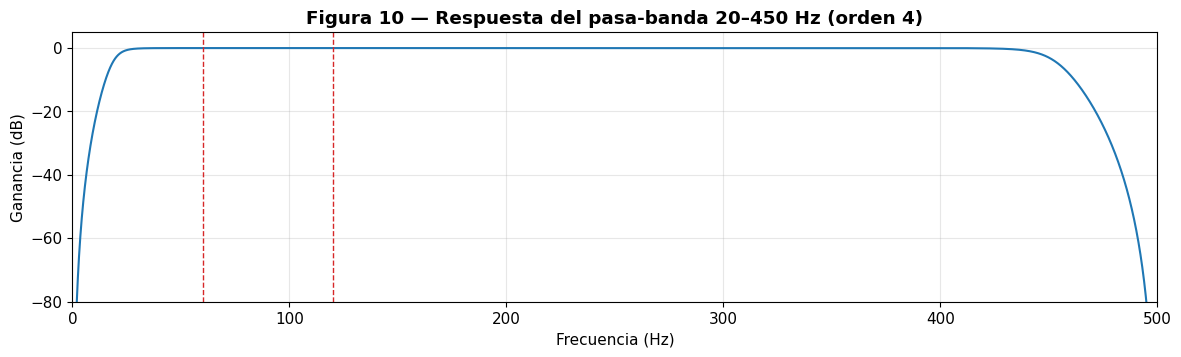

In [56]:
# =================== PARÁMETROS MODIFICABLES ===================
fc_baja = 20.0    # Hz (elimina movimiento y deriva)
fc_alta = 450.0   # Hz (la frecuencia de Nyquist es Fs/2 = 500 Hz)
orden_pb = 4
# ===============================================================

sos_pasabanda = signal.butter(orden_pb, [fc_baja, fc_alta], btype="bandpass", fs=Fs, output="sos")
emg_pasabanda = signal.sosfiltfilt(sos_pasabanda, emg_contaminado)

w, h = respuesta_sos(sos_pasabanda, Fs)
graficar_respuesta(w, h, f"Figura 10 — Respuesta del pasa-banda {fc_baja:g}–{fc_alta:g} Hz (orden {orden_pb})", marcas=(f1, f2))

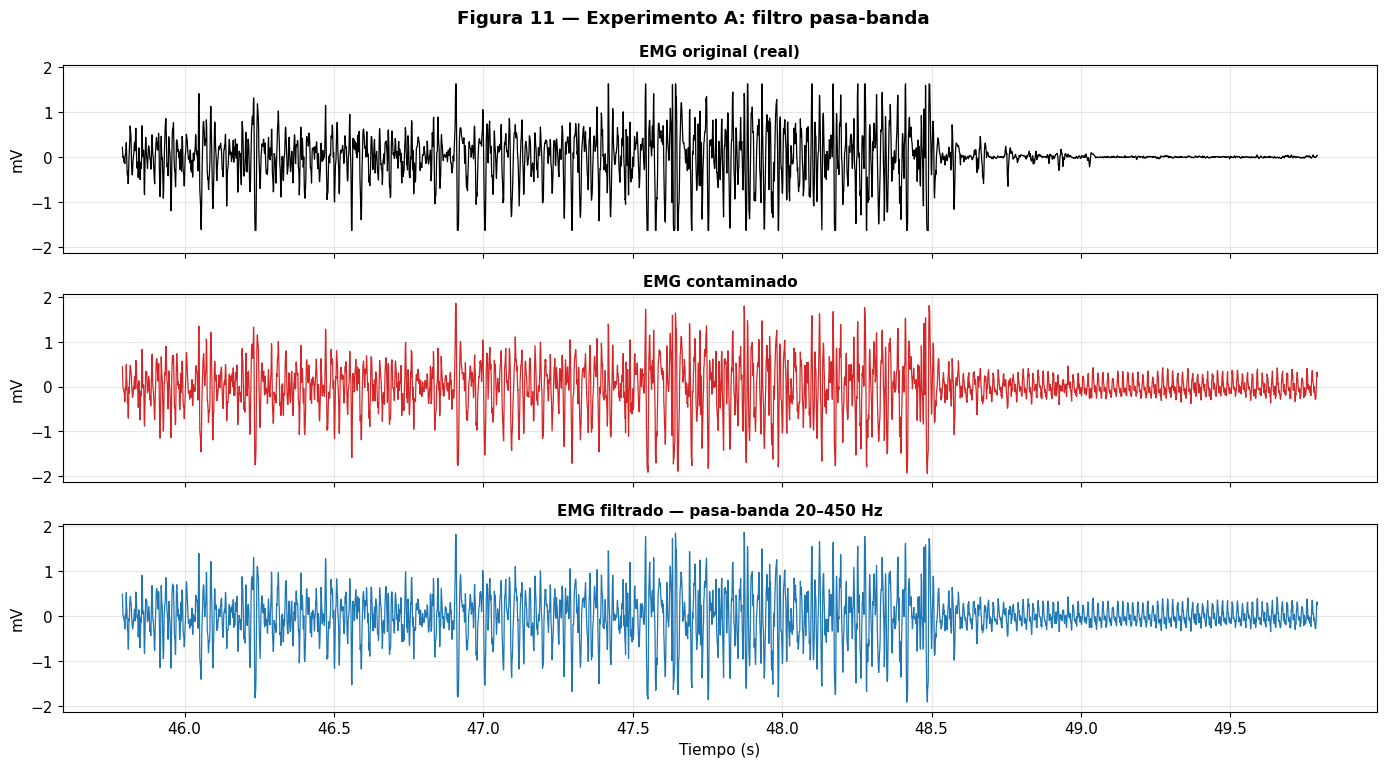

In [57]:
def comparar_senales(lista, titulo_general, mascara=zoom):
    """Grafica varias señales (titulo, señal, color) apiladas en la misma ventana temporal."""
    fig, ejes = plt.subplots(len(lista), 1, figsize=(14, 2.6 * len(lista)), sharex=True, sharey=True)
    for eje, (titulo, senal, color) in zip(ejes, lista):
        eje.plot(t[mascara], senal[mascara], color=color, lw=0.9)
        eje.set_title(titulo, fontsize=11); eje.set_ylabel("mV")
    ejes[-1].set_xlabel("Tiempo (s)")
    fig.suptitle(titulo_general, fontweight="bold")
    plt.tight_layout(); plt.show()

comparar_senales([
    ("EMG original (real)", emg_original, "black"),
    ("EMG contaminado", emg_contaminado, "tab:red"),
    (f"EMG filtrado — pasa-banda {fc_baja:g}–{fc_alta:g} Hz", emg_pasabanda, "tab:blue"),
], "Figura 11 — Experimento A: filtro pasa-banda")

### 🔎 Interpretación — Experimento A
- **¿Qué se eliminó?** Lo que está **fuera de 20 – 450 Hz**: deriva y movimiento lento, y el ruido gaussiano por debajo de 20 Hz (y por encima de 450 Hz).
- **¿Qué NO se eliminó?** Las interferencias de **60 y 120 Hz**, porque **están dentro de la banda de paso**. A diferencia del ECG (0.5 – 40 Hz), con EMG el pasa-banda **no** resuelve el problema de la red eléctrica. Tampoco se elimina el ruido gaussiano que cae dentro de 20 – 450 Hz: comparte frecuencias con el EMG.
- **¿Qué se pudo afectar?** El EMG real por debajo de 20 Hz (poco) y por encima de 450 Hz (casi nada).

## 4.3 Experimento B — Filtro notch

El notch elimina **una frecuencia concreta** y deja prácticamente intacto el resto del espectro. El **factor de calidad** $Q$ controla el ancho de la muesca: $\text{ancho} \approx f_0 / Q$.

**B1:** notch solo en $f_1$. **B2:** dos notch en cascada ($f_1$ y $f_2$).

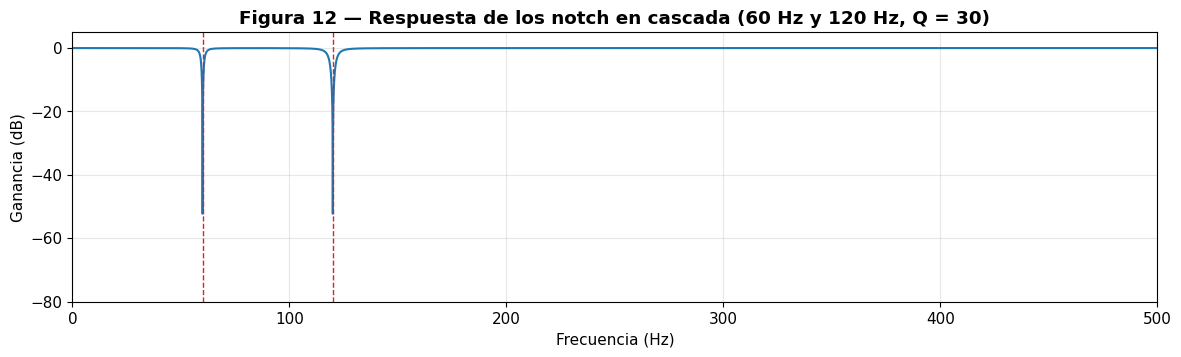

In [58]:
Q = 30   # factor de calidad (mayor Q → muesca más estrecha)

b_notch1, a_notch1 = signal.iirnotch(f1, Q, fs=Fs)
b_notch2, a_notch2 = signal.iirnotch(f2, Q, fs=Fs)

# B1: solo f1
emg_notch_f1 = signal.filtfilt(b_notch1, a_notch1, emg_contaminado)
# B2: f1 y luego f2 (cascada)
emg_notch_f1f2 = signal.filtfilt(b_notch2, a_notch2, emg_notch_f1)

# Respuesta en frecuencia de la cascada (producto de ambas respuestas)
w, h1 = signal.freqz(b_notch1, a_notch1, worN=16384, fs=Fs)
_, h2 = signal.freqz(b_notch2, a_notch2, worN=16384, fs=Fs)
graficar_respuesta(w, h1 * h2, f"Figura 12 — Respuesta de los notch en cascada ({f1} Hz y {f2} Hz, Q = {Q})", marcas=(f1, f2))

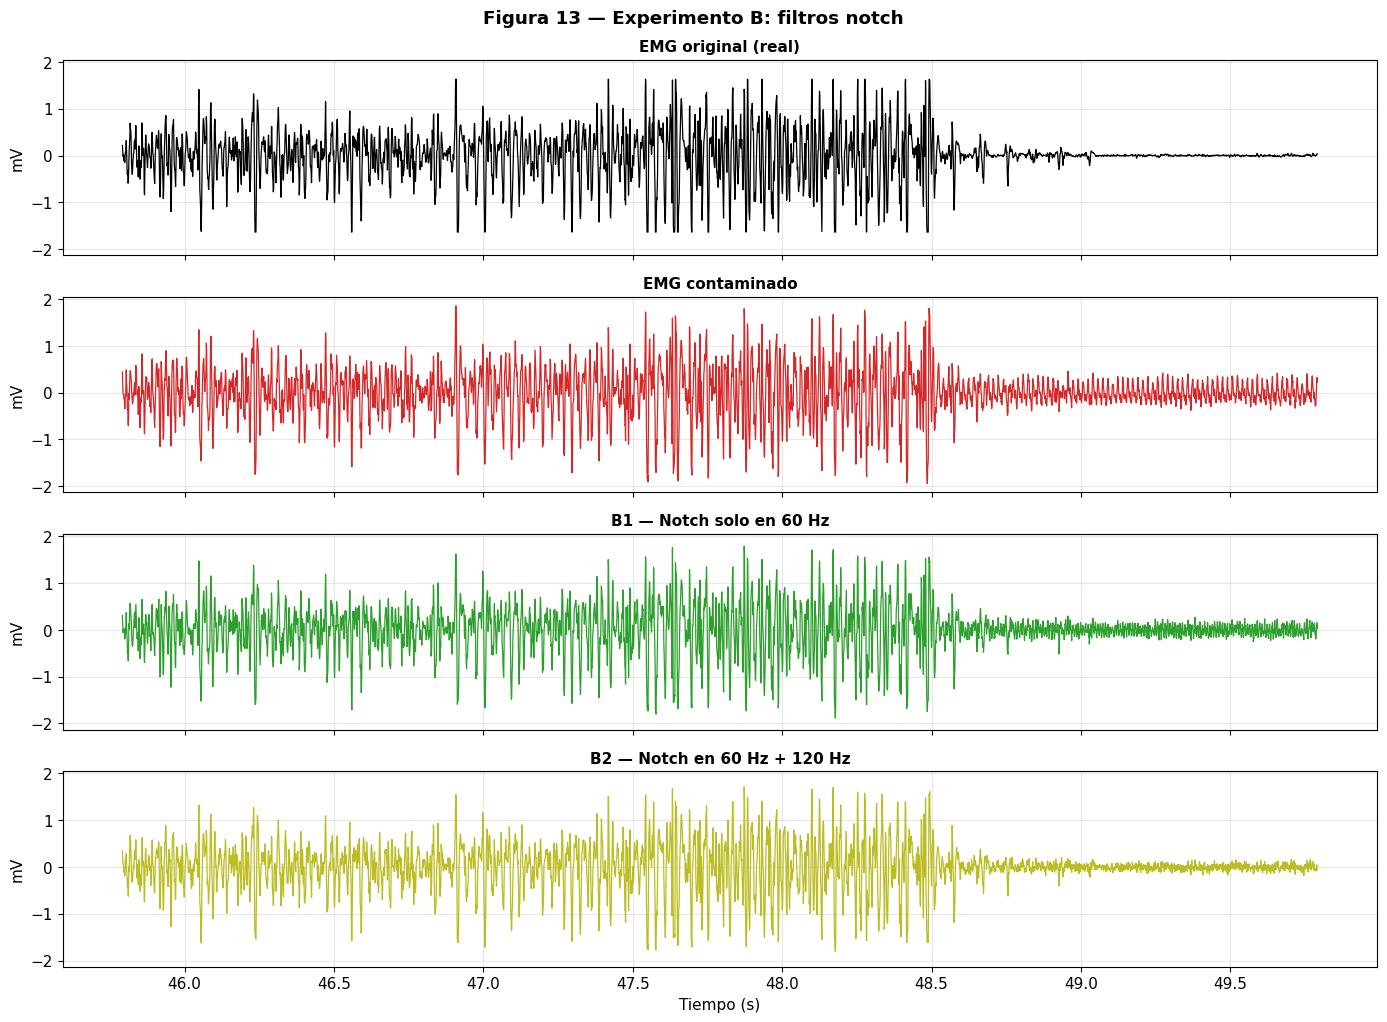

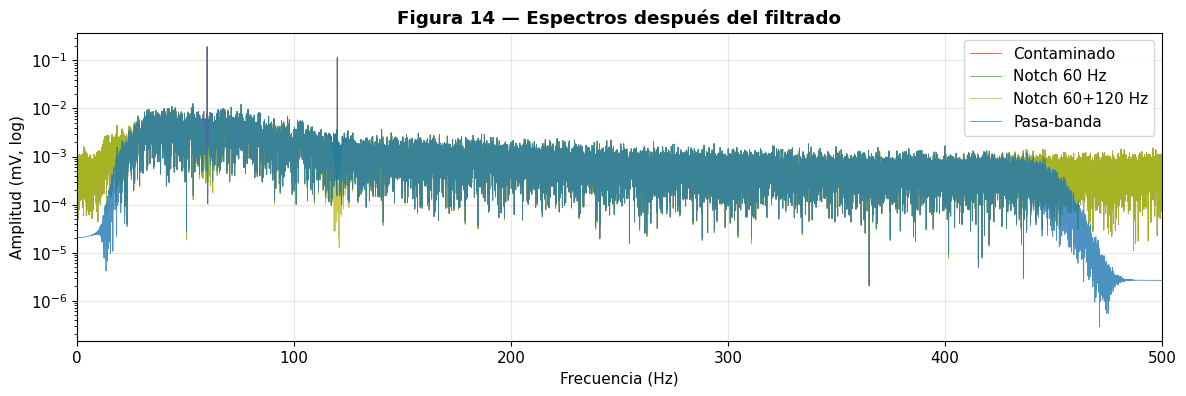

In [59]:
comparar_senales([
    ("EMG original (real)", emg_original, "black"),
    ("EMG contaminado", emg_contaminado, "tab:red"),
    (f"B1 — Notch solo en {f1} Hz", emg_notch_f1, "tab:green"),
    (f"B2 — Notch en {f1} Hz + {f2} Hz", emg_notch_f1f2, "tab:olive"),
], "Figura 13 — Experimento B: filtros notch")

# Espectros después de cada filtrado
fig, eje = plt.subplots(figsize=(14, 4))
for etiqueta, senal, color in [("Contaminado", emg_contaminado, "tab:red"),
                               (f"Notch {f1} Hz", emg_notch_f1, "tab:green"),
                               (f"Notch {f1}+{f2} Hz", emg_notch_f1f2, "tab:olive"),
                               ("Pasa-banda", emg_pasabanda, "tab:blue")]:
    fr, am = espectro_amplitud(senal, Fs)
    eje.semilogy(fr, am, lw=0.6, label=etiqueta, color=color, alpha=0.8)
eje.set_xlim(0, F_MAX_GRAFICO); eje.legend()
eje.set_title("Figura 14 — Espectros después del filtrado")
eje.set_xlabel("Frecuencia (Hz)"); eje.set_ylabel("Amplitud (mV, log)")
plt.show()

### 🔎 Interpretación — Experimento B
- **B1** elimina el pico en $f_1$, pero el de $f_2$ sigue ahí: el notch solo actúa donde se lo indicamos.
- **B2** elimina ambos picos, pero el **ruido gaussiano permanece** (el notch no reduce el ruido de banda ancha).
- **Ventaja:** el notch altera muy poco la morfología del EMG porque solo "corta" una banda estrecha.
- **Limitación:** exige conocer la frecuencia exacta y que esta no cambie en el tiempo.

### ❓ Pregunta al estudiante
Cambia `Q` a 5 y luego a 100. ¿Qué ocurre con el ancho de la muesca (Figura 12) y con la señal filtrada?

✍️ **Respuesta:**

Con **Q = 5** la muesca es muy ancha (≈ 12 Hz) y se lleva parte del EMG vecino a 60 y 120 Hz: SNR = 6.7 dB y r = 0.89 (aplicado al original solo, la SNR cae a 8.4 dB). Con **Q = 30** se obtiene 10.0 dB y r = 0.95 (17.2 dB sobre el original). Con **Q = 100** la muesca es muy estrecha (≈ 0.6 Hz): 10.5 dB, r = 0.96 y casi no distorsiona el original (22.3 dB). Pero un Q muy alto exige conocer la frecuencia exacta de la red: si esta se desvía unas décimas de hertz, la muesca estrecha deja pasar la interferencia.

## 4.4 Comparación cuantitativa

Las métricas **complementan** (no reemplazan) la evaluación visual:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{N}\sum (x - \hat{x})^2}$ | Error promedio (mV). **Menor es mejor.** |
| **SNR** | $10\log_{10}\frac{\sum x^2}{\sum (x-\hat{x})^2}$ | Relación señal/error en dB. **Mayor es mejor.** |
| **Correlación** $r$ | coeficiente de Pearson | Similitud de forma (1 = idéntica). |

donde $x$ es el EMG original y $\hat{x}$ la señal evaluada. Excluimos los primeros y últimos 2 s para evitar efectos de borde (y el tiempo de convergencia del filtro adaptativo que veremos luego).

In [60]:
MARGEN_S = 2.0
evaluacion = (t >= MARGEN_S) & (t <= t[-1] - MARGEN_S)

def calcular_metricas(referencia, estimada, mascara=evaluacion):
    x, y = referencia[mascara], estimada[mascara]
    error = y - x
    rmse = np.sqrt(np.mean(error ** 2))
    snr = 10 * np.log10(np.sum(x ** 2) / np.sum(error ** 2))
    r = np.corrcoef(x, y)[0, 1]
    return {"RMSE (mV)": rmse, "SNR (dB)": snr, "Correlación r": r}

resultados = {
    "Contaminado (sin filtrar)": calcular_metricas(emg_original, emg_contaminado),
    "A — Pasa-banda": calcular_metricas(emg_original, emg_pasabanda),
    f"B1 — Notch {f1} Hz": calcular_metricas(emg_original, emg_notch_f1),
    f"B2 — Notch {f1}+{f2} Hz": calcular_metricas(emg_original, emg_notch_f1f2),
}
pd.DataFrame(resultados).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.1680,1.5149,0.7663
A — Pasa-banda,0.1674,1.5431,0.7622
B1 — Notch 60 Hz,0.1022,5.8264,0.8842
B2 — Notch 60+120 Hz,0.0633,9.9919,0.9503


### ¿Cuánto modifica el filtro a la propia señal original?

Un detalle importante: los filtros **también** cambian el EMG original. Para separar "ruido no eliminado" de "distorsión del filtro", filtramos el **original limpio** y lo comparamos consigo mismo.

In [61]:
emg_original_pasabanda = signal.sosfiltfilt(sos_pasabanda, emg_original)
emg_original_notch = signal.filtfilt(b_notch2, a_notch2, signal.filtfilt(b_notch1, a_notch1, emg_original))

pd.DataFrame({
    "Pasa-banda aplicado al ORIGINAL": calcular_metricas(emg_original, emg_original_pasabanda),
    "Notch f1+f2 aplicado al ORIGINAL": calcular_metricas(emg_original, emg_original_notch),
}).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Pasa-banda aplicado al ORIGINAL,0.0190,20.4637,0.9955
Notch f1+f2 aplicado al ORIGINAL,0.0276,17.1973,0.9907


### 🔎 Interpretación
- Si el pasa-banda aplicado al original **ya** produce un error apreciable, parte del "error" del Experimento A **no es ruido residual**, sino **distorsión introducida por el filtro**. En EMG este efecto es pequeño porque la señal casi no tiene energía fuera de 20 – 450 Hz.
- El notch casi no modifica el original → distorsión mínima, pero tampoco reduce el ruido gaussiano.
- Conclusión: **ninguna métrica aislada cuenta toda la historia**. Además, la "señal original" ya trae algo de ruido propio, por lo que la SNR calculada respecto a ella es una referencia práctica, no una verdad absoluta.

### ❓ Pregunta al estudiante
¿Qué filtro obtuvo mejor SNR? ¿Coincide con lo que observaste visualmente? Explica cualquier diferencia.

✍️ **Respuesta:**

El mejor SNR lo obtuvo el **notch en 60 + 120 Hz (10.0 dB, r = 0.95)**, seguido del LMS (9.5 dB, r = 0.95). El pasa-banda 20 – 450 Hz casi no mejora la señal, porque las interferencias de 60 y 120 Hz están dentro de su banda de paso. Visualmente coincide, en la Figura 13 el notch deja una señal parecida a la original y el pasa-banda conserva la oscilación regular en los tramos débiles. Una diferencia: el SNR global está dominado por la contracción fuerte (la que más energía tiene) y oculta que en los tramos de reposo la recuperación es mala (SNR del notch ≈ −4 dB en la fase de reposo, 7.6 dB en la leve y 14.3 dB en la fuerte). Además, 10 dB es casi el tope posible para un método que solo quita interferencias: el ruido gaussiano (σ = 0.3·σ_señal) limita el SNR a $10\log_{10}(1/0.09) \approx 10.5$ dB.

---
# 🟦 BLOQUE 5 — Filtros adaptativos y Transformada Wavelet *(20 min)*

## 5.1 ¿Qué es un filtro adaptativo?

Un filtro **convencional** tiene coeficientes **fijos**: se diseña una vez y se aplica igual a toda la señal. Un filtro **adaptativo** **modifica sus coeficientes muestra a muestra** en función de la información que recibe, por lo que puede seguir interferencias cuya amplitud o fase cambian en el tiempo.

```text
Señal contaminada d[n] ──────────────────────────►(+)──► e[n] = EMG estimado
                                                    ▲(−)
                                                    │
señal de referencia x[n] ──► Filtro adaptativo ──► y[n] = interferencia estimada
                                  ▲
                                  └──── se ajusta usando el error e[n]
```

| Concepto | Significado en este laboratorio |
|---|---|
| **Señal de referencia** $x[n]$ | Señal **correlacionada con la interferencia** pero no con el EMG (aquí: senos y cosenos de $f_1$ y $f_2$). En la práctica puede provenir de un sensor que capta la red eléctrica. |
| **Coeficientes** $w$ | Pesos que el filtro ajusta para "imitar" la interferencia. |
| **Salida** $y[n] = w^T x[n]$ | Estimación de la interferencia. |
| **Error** $e[n] = d[n] - y[n]$ | Lo que queda al restar la interferencia estimada: **es nuestro EMG limpio**. |
| **Adaptación (LMS)** | $w[n+1] = w[n] + 2\mu\, e[n]\, x[n]$ |
| **Paso** $\mu$ | Velocidad de aprendizaje: grande → rápido pero inestable/distorsionante; pequeño → lento pero preciso. |

El algoritmo **LMS** (*Least Mean Squares*) minimiza poco a poco la potencia del error. Como el EMG no está correlacionado con la referencia, la única forma de reducir el error es **cancelar la interferencia**.

In [62]:
def filtro_lms(senal_contaminada, referencias, mu):
    """
    Cancelador adaptativo de interferencias con algoritmo LMS (versión didáctica).
    senal_contaminada : vector d[n] de tamaño N
    referencias       : matriz N x M (cada columna es una señal de referencia)
    mu                : paso de adaptación
    Devuelve: e (señal limpia estimada), y (interferencia estimada), historial de pesos
    """
    N, M = referencias.shape
    w = np.zeros(M)                       # los coeficientes empiezan en cero: el filtro "no sabe nada"
    y = np.zeros(N)
    e = np.zeros(N)
    historial_w = np.zeros((N, M))
    for n in range(N):
        x_n = referencias[n]              # vector de referencia en el instante n
        y[n] = w @ x_n                    # 1) estimar la interferencia
        e[n] = senal_contaminada[n] - y[n]  # 2) calcular el error (EMG estimado)
        w = w + 2 * mu * e[n] * x_n       # 3) actualizar los coeficientes (LMS)
        historial_w[n] = w
    return e, y, historial_w

# Referencias: seno y coseno de cada frecuencia (permiten ajustar amplitud Y fase)
referencias = np.column_stack([
    np.sin(2 * np.pi * f1 * t), np.cos(2 * np.pi * f1 * t),
    np.sin(2 * np.pi * f2 * t), np.cos(2 * np.pi * f2 * t),
])

MU = 0.005   # =================== PARÁMETRO MODIFICABLE ===================
emg_lms, interferencia_estimada, pesos = filtro_lms(emg_contaminado, referencias, MU)
print("Filtrado adaptativo completado.")

Filtrado adaptativo completado.


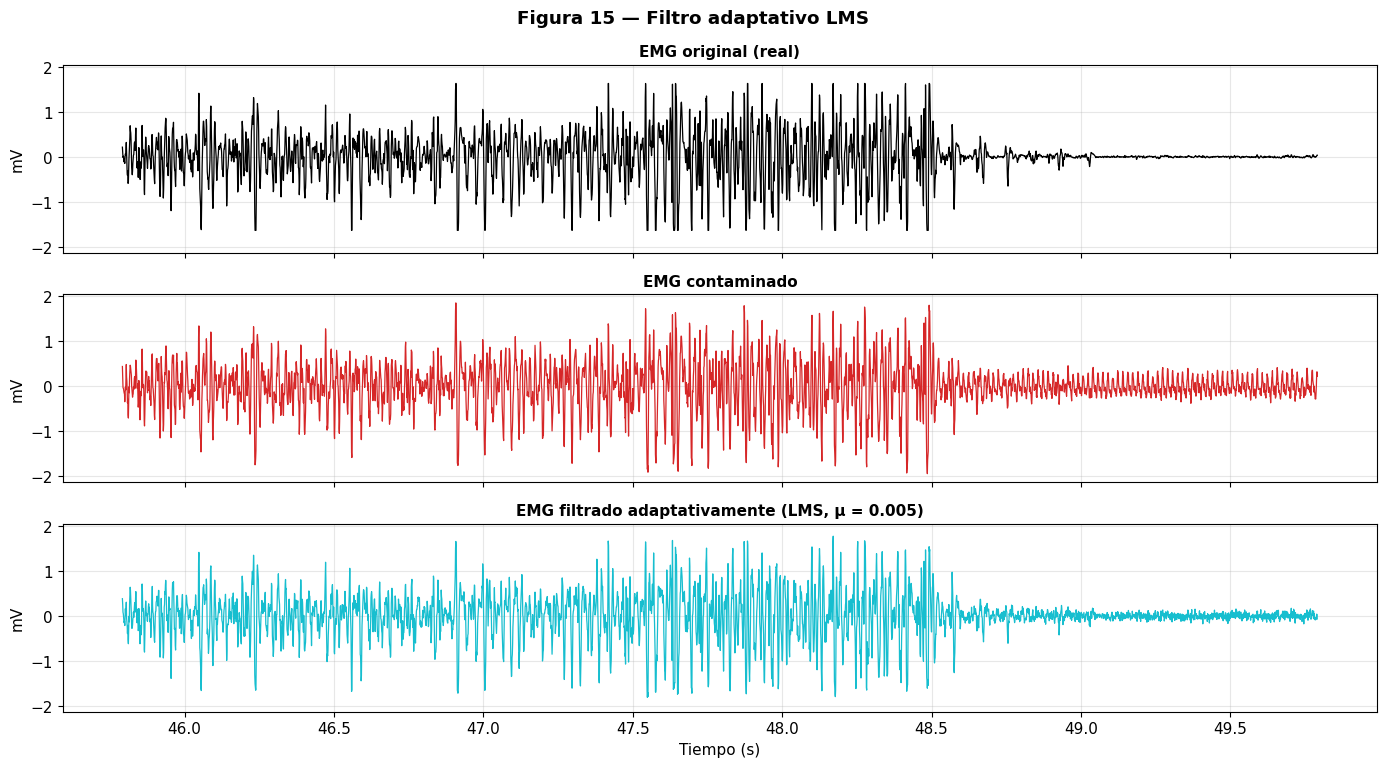

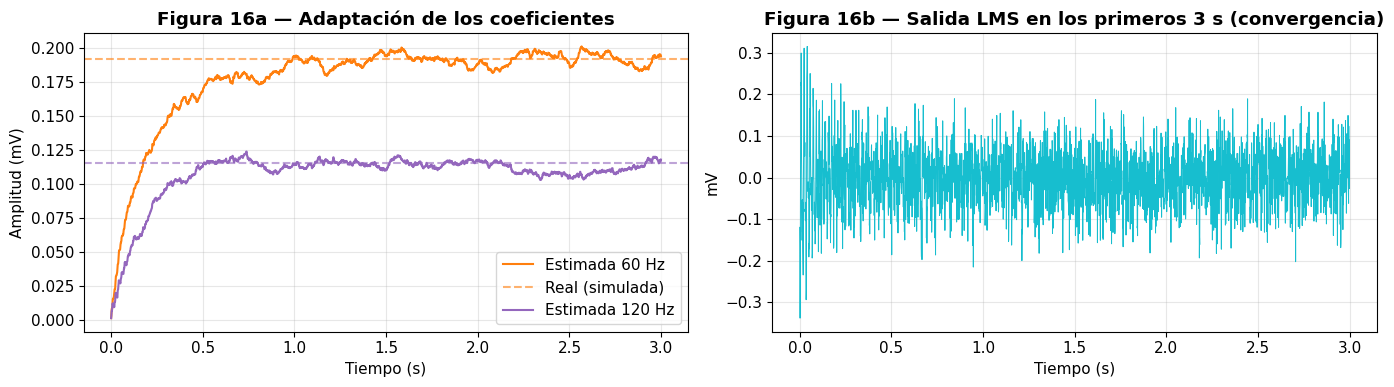

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.1680,1.5149,0.7663
A — Pasa-banda,0.1674,1.5431,0.7622
B1 — Notch 60 Hz,0.1022,5.8264,0.8842
B2 — Notch 60+120 Hz,0.0633,9.9919,0.9503
LMS adaptativo,0.0673,9.4567,0.9460


In [63]:
comparar_senales([
    ("EMG original (real)", emg_original, "black"),
    ("EMG contaminado", emg_contaminado, "tab:red"),
    (f"EMG filtrado adaptativamente (LMS, μ = {MU})", emg_lms, "tab:cyan"),
], "Figura 15 — Filtro adaptativo LMS")

# ¿Cómo "aprende" el filtro? Amplitud estimada de cada interferencia en el tiempo
amplitud_est_1 = np.hypot(pesos[:, 0], pesos[:, 1])
amplitud_est_2 = np.hypot(pesos[:, 2], pesos[:, 3])
primeros = t < 3.0

fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
ejes[0].plot(t[primeros], amplitud_est_1[primeros], label=f"Estimada {f1} Hz", color="tab:orange")
ejes[0].axhline(amplitud_1, ls="--", color="tab:orange", alpha=0.6, label="Real (simulada)")
ejes[0].plot(t[primeros], amplitud_est_2[primeros], label=f"Estimada {f2} Hz", color="tab:purple")
ejes[0].axhline(amplitud_2, ls="--", color="tab:purple", alpha=0.6)
ejes[0].set_title("Figura 16a — Adaptación de los coeficientes")
ejes[0].set_xlabel("Tiempo (s)"); ejes[0].set_ylabel("Amplitud (mV)"); ejes[0].legend()

ejes[1].plot(t[primeros], emg_lms[primeros], color="tab:cyan", lw=0.7)
ejes[1].set_title("Figura 16b — Salida LMS en los primeros 3 s (convergencia)")
ejes[1].set_xlabel("Tiempo (s)"); ejes[1].set_ylabel("mV")
plt.tight_layout(); plt.show()

resultados["LMS adaptativo"] = calcular_metricas(emg_original, emg_lms)
pd.DataFrame(resultados).T.round(4)

### 🔎 Interpretación — Filtro adaptativo
- Al inicio los coeficientes valen cero: la salida todavía contiene la interferencia. En unos cientos de milisegundos los coeficientes convergen a la amplitud real de cada interferencia (Figura 16a).
- Una vez adaptado, el LMS cancela $f_1$ y $f_2$ con muy poca alteración del EMG.
- **El ruido gaussiano permanece**: no está correlacionado con la referencia, así que el filtro no puede "aprenderlo".
- Su gran ventaja frente al notch aparece cuando la interferencia cambia (amplitud/fase variables): el LMS la sigue; el notch fijo no se entera.

### ❓ Pregunta al estudiante
Cambia `MU` a 0.0005 y a 0.05. ¿Qué pasa con la velocidad de convergencia (Figura 16a) y con la calidad de la señal?

✍️ **Respuesta:**

Con **μ = 0.0005** el filtro converge muy lento (≈ 5 s para llegar al 90 % de la amplitud de 60 Hz) pero es muy preciso (SNR 10.6 dB). Con **μ = 0.005** converge en ≈ 0.5 s y da 9.5 dB (r = 0.95). Con **μ = 0.05** converge casi al instante (≈ 0.03 s), pero el EMG, que actúa como "ruido" para el algoritmo, hace oscilar los coeficientes y el SNR cae a 3.9 dB (r = 0.79). Hay un compromiso: μ grande → rápido pero ruidoso; μ pequeño → lento pero preciso. (Nota: las métricas excluyen los primeros 2 s, por eso el μ más pequeño no se penaliza por su convergencia lenta.)

## 5.2 Transformada Wavelet

> ### ¿Para qué sirve la Transformada Wavelet en el procesamiento de señales biomédicas?

La FFT nos dice **qué frecuencias** hay en la señal, pero **no cuándo** aparecen (analiza la señal completa de forma global). La **Transformada Wavelet** descompone la señal usando pequeñas "ondas" (*wavelets*) de duración limitada, a distintas **escalas**, y así indica **qué frecuencias hay y en qué momento**.

- **Escalas pequeñas** → detalles rápidos (alta frecuencia), bien localizados en el tiempo.
- **Escalas grandes** → tendencias lentas (baja frecuencia).

Esto encaja con el EMG, que es una señal **no estacionaria**: su amplitud y contenido en frecuencia cambian con la fuerza y con el tiempo (reposo → contracción → reposo).
- las **contracciones** son eventos localizados en el tiempo (la Wavelet muestra *cuándo* ocurren y *con qué intensidad*);
- el **ruido** de banda ancha se reparte en los detalles finos con coeficientes pequeños;
- la **deriva de base** vive en la aproximación más gruesa.

> ⚠️ **Matiz importante para EMG:** el EMG es en sí mismo una señal aleatoria de banda ancha, por lo que **no es "esparso"** como un ECG (pocos picos grandes). Umbralizar los coeficientes puede eliminar también parte del EMG útil. Veremos qué tan bien funciona.

### Descomposición Wavelet Discreta (DWT)

En cada nivel la señal se divide en una **aproximación** (A, parte lenta) y un **detalle** (D, parte rápida); la aproximación se vuelve a dividir:

```text
Señal ─┬─► D1 (Fs/4 – Fs/2)
       └─► A1 ─┬─► D2 (Fs/8 – Fs/4)
               └─► A2 ─┬─► D3 ...
                       └─► ... ─► A_L (la parte más lenta)
```

Usaremos la wavelet **Daubechies 4 (`db4`)**, de la familia Daubechies, que se usa a menudo en EMG porque su forma se parece a la de un potencial de acción de unidad motora.

In [64]:
WAVELET = "db4"
nivel_max = pywt.dwt_max_level(len(emg_original), pywt.Wavelet(WAVELET).dec_len)
NIVEL = min(8, nivel_max)

# Banda de frecuencias aproximada de cada nivel
print(f"Wavelet: {WAVELET} | Niveles: {NIVEL}\n")
print(f"A{NIVEL}: 0 – {Fs / 2**(NIVEL+1):.1f} Hz (aproximación)")
for j in range(NIVEL, 0, -1):
    print(f"D{j}: {Fs / 2**(j+1):.1f} – {Fs / 2**j:.1f} Hz")
print(f"\nInterferencia 1 ({f1} Hz) y 2 ({f2} Hz): ubícalas en la tabla anterior.")

def componentes_por_nivel(x, wavelet, nivel):
    """Reconstruye por separado la contribución de la aproximación y de cada detalle (en el dominio del tiempo)."""
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    componentes = {}
    nombres = [f"A{nivel}"] + [f"D{j}" for j in range(nivel, 0, -1)]
    for i, nombre in enumerate(nombres):
        coefs_solo = [c if k == i else np.zeros_like(c) for k, c in enumerate(coefs)]
        componentes[nombre] = pywt.waverec(coefs_solo, wavelet)[:len(x)]
    return componentes

comp_original = componentes_por_nivel(emg_original, WAVELET, NIVEL)
comp_contaminado = componentes_por_nivel(emg_contaminado, WAVELET, NIVEL)

Wavelet: db4 | Niveles: 8

A8: 0 – 2.0 Hz (aproximación)
D8: 2.0 – 3.9 Hz
D7: 3.9 – 7.8 Hz
D6: 7.8 – 15.6 Hz
D5: 15.6 – 31.2 Hz
D4: 31.2 – 62.5 Hz
D3: 62.5 – 125.0 Hz
D2: 125.0 – 250.0 Hz
D1: 250.0 – 500.0 Hz

Interferencia 1 (60 Hz) y 2 (120 Hz): ubícalas en la tabla anterior.


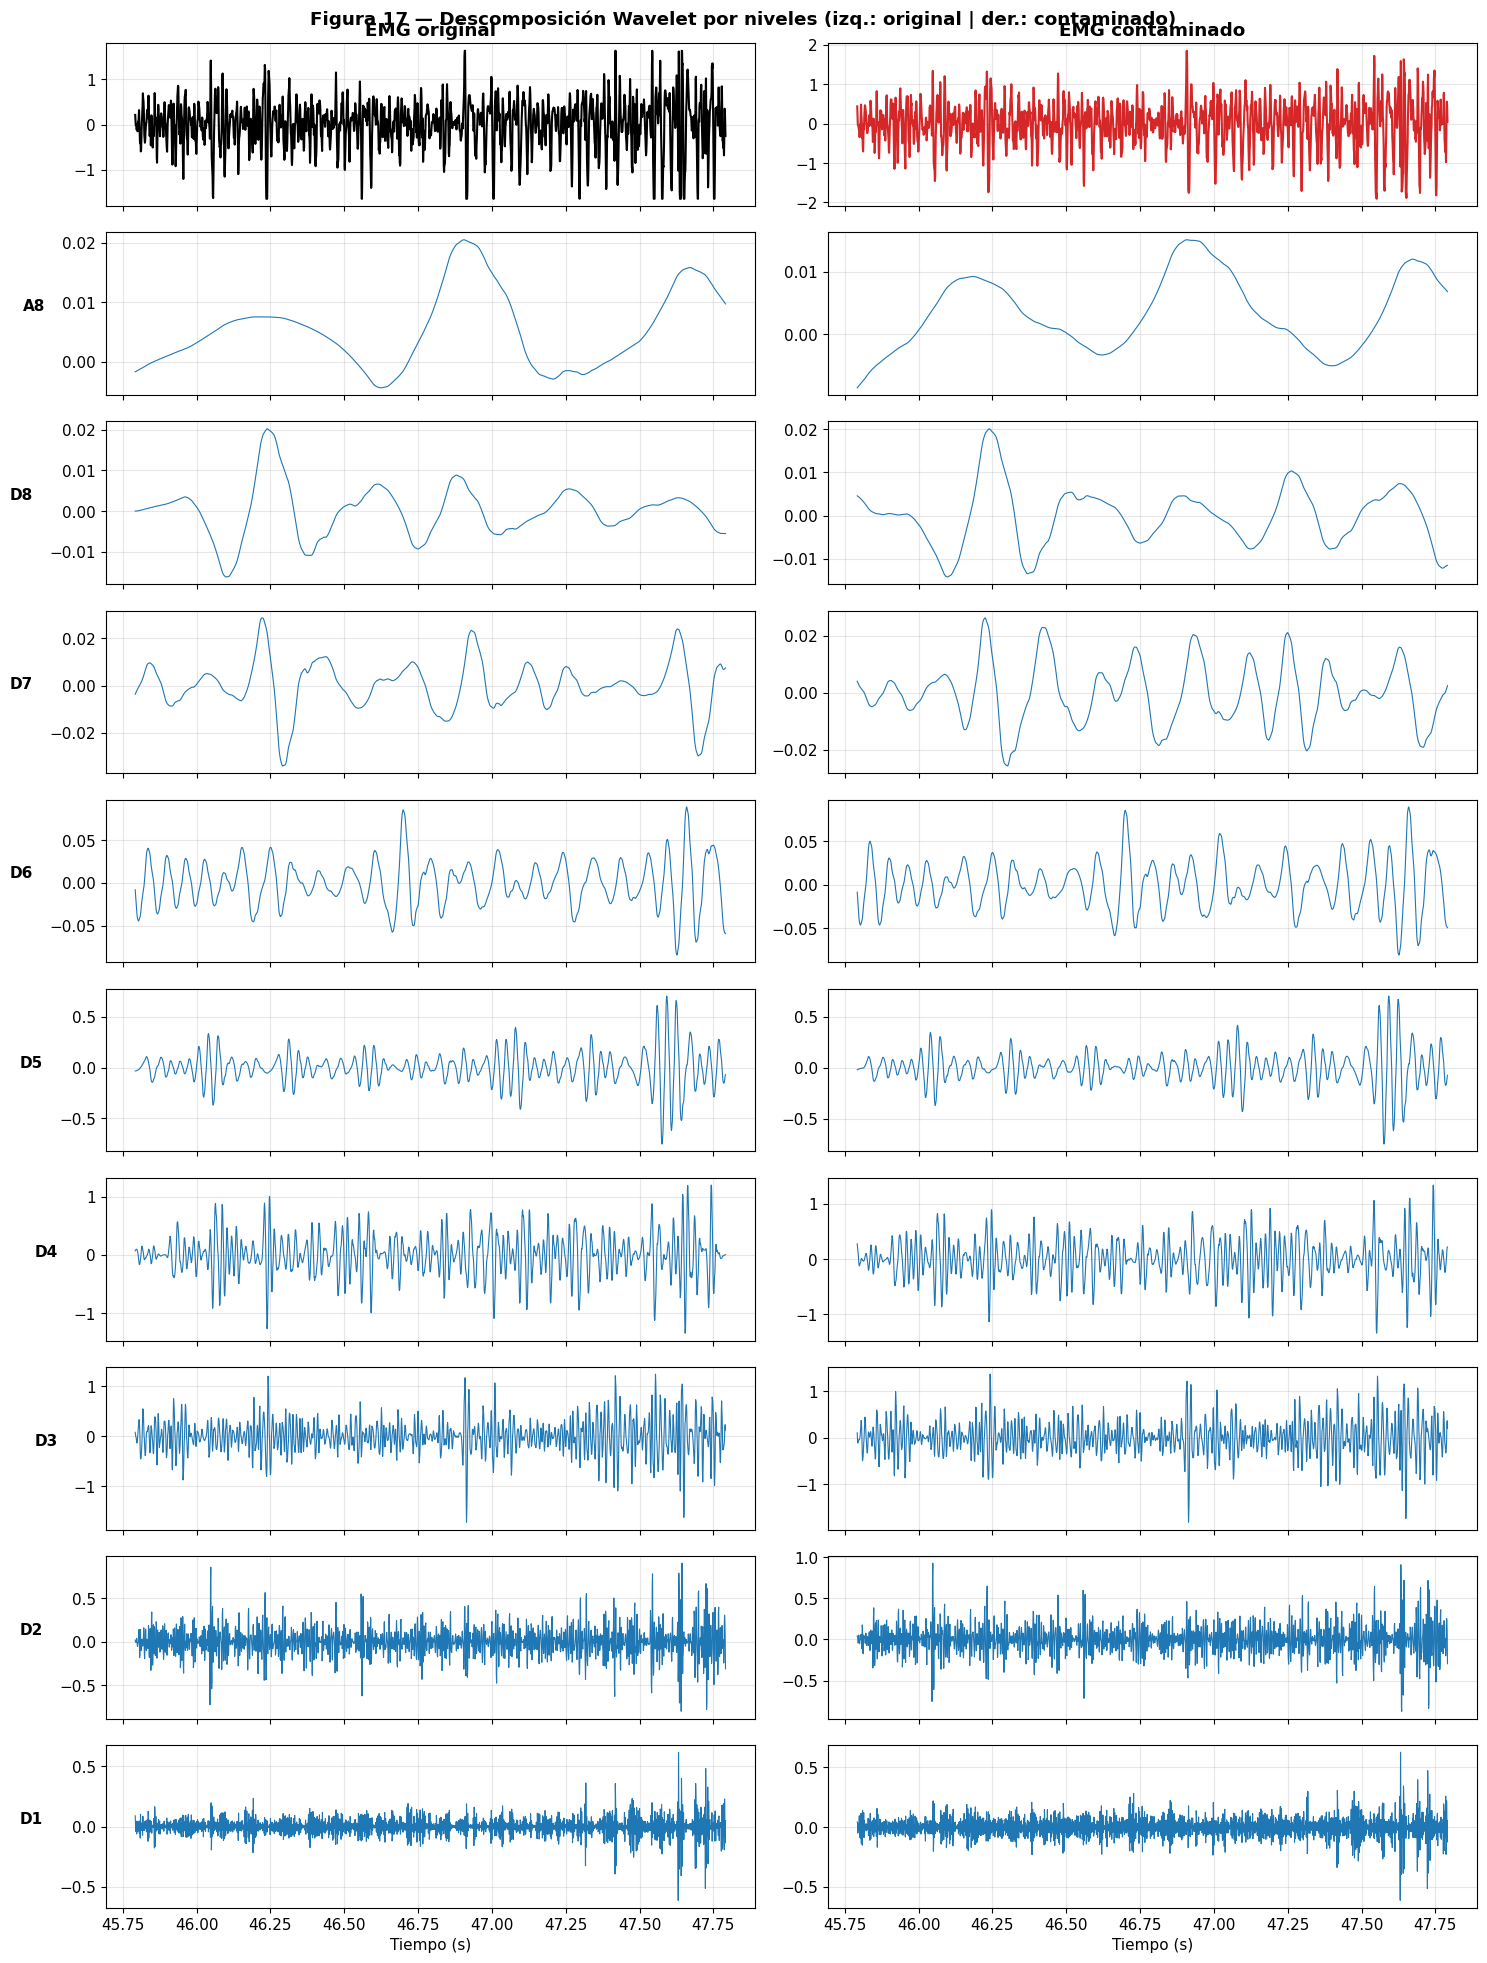

In [65]:
ventana_2s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 2.0)
nombres = list(comp_original.keys())

fig, ejes = plt.subplots(len(nombres) + 1, 2, figsize=(15, 2 * (len(nombres) + 1)), sharex=True)
ejes[0, 0].plot(t[ventana_2s], emg_original[ventana_2s], color="black"); ejes[0, 0].set_title("EMG original")
ejes[0, 1].plot(t[ventana_2s], emg_contaminado[ventana_2s], color="tab:red"); ejes[0, 1].set_title("EMG contaminado")
for i, nombre in enumerate(nombres, start=1):
    ejes[i, 0].plot(t[ventana_2s], comp_original[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 1].plot(t[ventana_2s], comp_contaminado[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 0].set_ylabel(nombre, rotation=0, labelpad=20, fontweight="bold")
ejes[-1, 0].set_xlabel("Tiempo (s)"); ejes[-1, 1].set_xlabel("Tiempo (s)")
fig.suptitle("Figura 17 — Descomposición Wavelet por niveles (izq.: original | der.: contaminado)", fontweight="bold")
plt.tight_layout(); plt.show()

### 🔎 Interpretación — Descomposición
- **D1, D2** (125 – 500 Hz): en el original hay poca energía (D2 contiene la cola alta del EMG); en el contaminado aparecen dominados por **ruido gaussiano**.
- **D3, D4** (31 – 125 Hz): aquí "caen" las interferencias de 120 Hz y 60 Hz (oscilaciones regulares). Son también las bandas donde el EMG tiene más energía, por eso interferencia y señal quedan mezcladas.
- **D5, D6** (8 – 31 Hz): poco EMG; más bien artefactos de movimiento.
- **A8 (aproximación, 0 – 2 Hz)**: tendencia lenta y deriva de línea de base.
- Observa que en los detalles la contracción aparece localizada en el tiempo: eso es lo que la FFT global no puede mostrar.

## 5.3 *Denoising* mediante Wavelet (umbralización)

Idea: los eventos importantes producen **pocos coeficientes grandes**; el ruido produce **muchos coeficientes pequeños**. Entonces:

1. Descomponer la señal (DWT).
2. Estimar el nivel de ruido con el detalle más fino: $\sigma = \text{mediana}(|D_1|)/0.6745$.
3. Calcular un umbral (universal): $\lambda = \sigma\sqrt{2\ln N}$.
4. **Umbralizar** los detalles: los coeficientes con $|c| < \lambda$ se anulan, los demás se reducen (*soft thresholding*).
5. Reconstruir la señal (IDWT).

Umbral universal aplicado: 0.2989


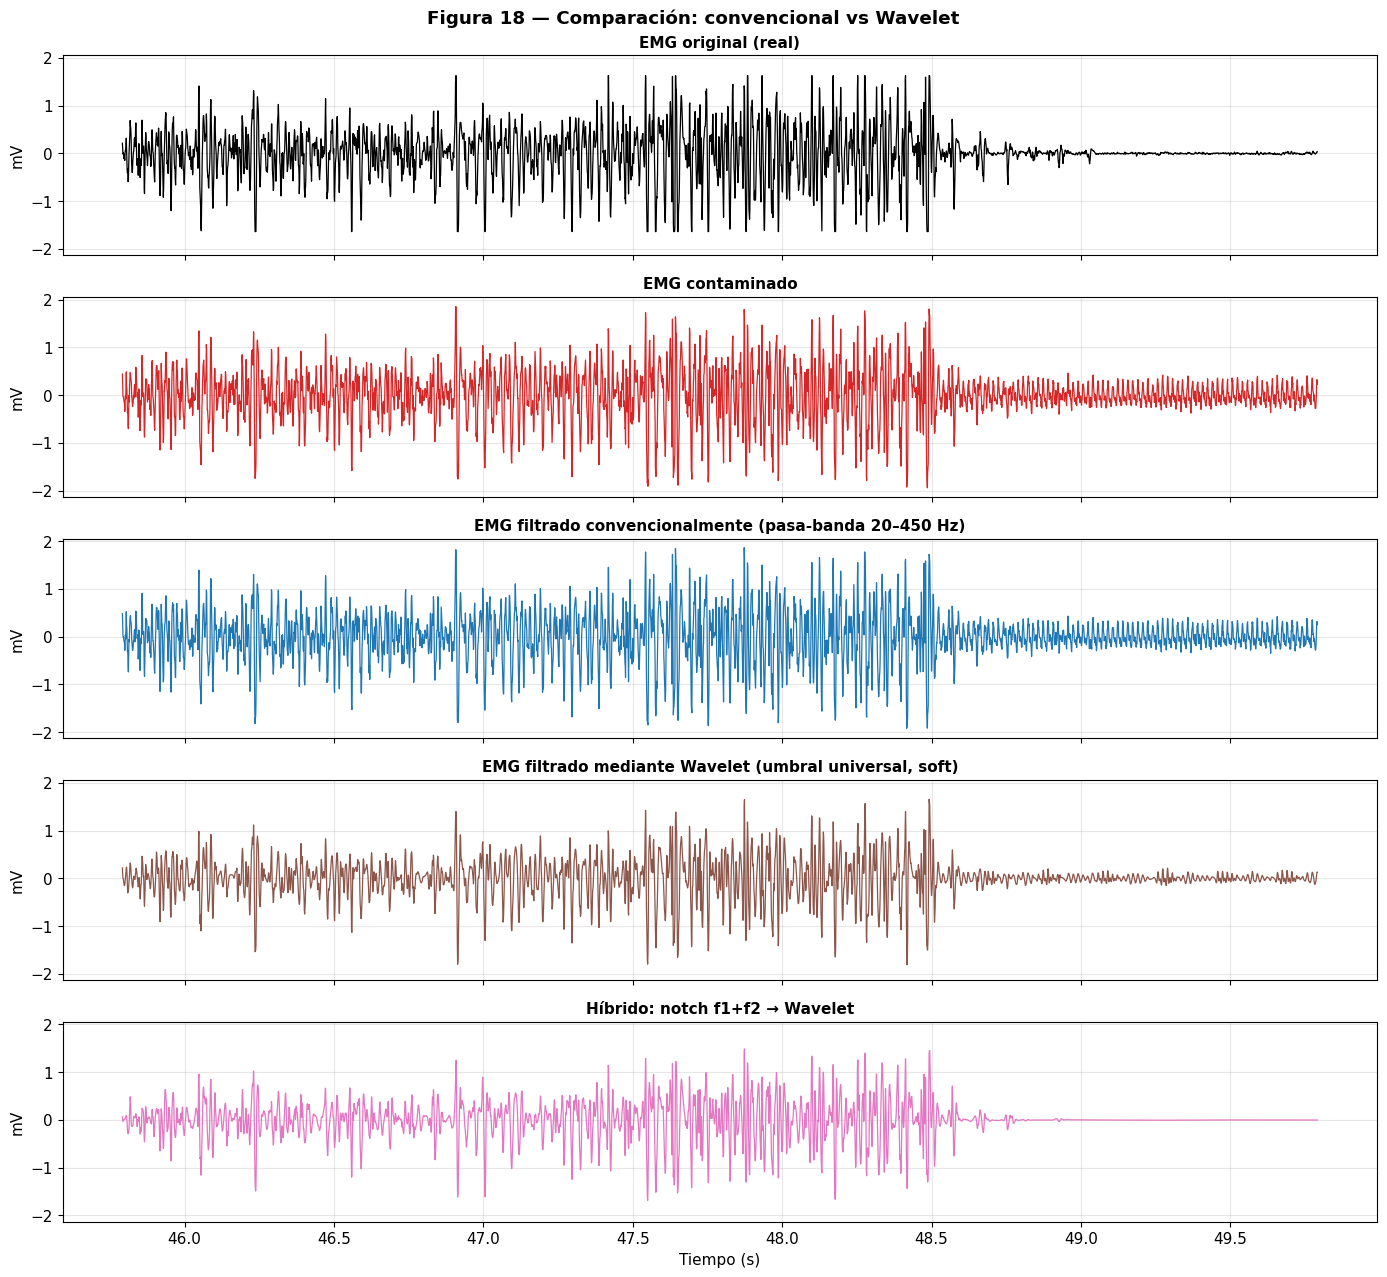

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.1680,1.5149,0.7663
A — Pasa-banda,0.1674,1.5431,0.7622
B1 — Notch 60 Hz,0.1022,5.8264,0.8842
B2 — Notch 60+120 Hz,0.0633,9.9919,0.9503
LMS adaptativo,0.0673,9.4567,0.9460
Wavelet (denoising),0.1084,5.3153,0.8404
Híbrido notch + Wavelet,0.0951,6.4571,0.9067


In [66]:
def denoising_wavelet(x, wavelet=WAVELET, nivel=NIVEL, modo="soft"):
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    sigma = np.median(np.abs(coefs[-1])) / 0.6745            # ruido estimado a partir de D1
    umbral = sigma * np.sqrt(2 * np.log(len(x)))              # umbral universal
    coefs_umbral = [coefs[0]] + [pywt.threshold(c, umbral, mode=modo) for c in coefs[1:]]
    x_limpia = pywt.waverec(coefs_umbral, wavelet)[:len(x)]
    return x_limpia, umbral

# 1) Wavelet aplicada directamente a la señal contaminada
emg_wavelet, umbral = denoising_wavelet(emg_contaminado)
# 2) Enfoque híbrido: primero notch (quita interferencias), luego wavelet (quita ruido gaussiano)
emg_hibrido, _ = denoising_wavelet(emg_notch_f1f2)

print(f"Umbral universal aplicado: {umbral:.4f}")

comparar_senales([
    ("EMG original (real)", emg_original, "black"),
    ("EMG contaminado", emg_contaminado, "tab:red"),
    (f"EMG filtrado convencionalmente (pasa-banda {fc_baja:g}–{fc_alta:g} Hz)", emg_pasabanda, "tab:blue"),
    ("EMG filtrado mediante Wavelet (umbral universal, soft)", emg_wavelet, "tab:brown"),
    ("Híbrido: notch f1+f2 → Wavelet", emg_hibrido, "tab:pink"),
], "Figura 18 — Comparación: convencional vs Wavelet")

resultados["Wavelet (denoising)"] = calcular_metricas(emg_original, emg_wavelet)
resultados["Híbrido notch + Wavelet"] = calcular_metricas(emg_original, emg_hibrido)
pd.DataFrame(resultados).T.round(4)

### 🔎 Interpretación — *Denoising* Wavelet
- La umbralización reduce el ruido gaussiano (banda ancha, coeficientes pequeños), pero en EMG también recorta el propio EMG: es de banda ancha y sus coeficientes pequeños (reposo, contracciones débiles) quedan por debajo del umbral y se anulan.
- Las interferencias sinusoidales intensas generan coeficientes grandes en D3–D4 que superan el umbral → sobreviven al *denoising*. La Wavelet no es la herramienta ideal para una interferencia de banda estrecha.
- El enfoque híbrido combina fortalezas: el notch quita las interferencias y la Wavelet el ruido de banda ancha.
- **Posibles distorsiones:** el *soft thresholding* reduce la amplitud del EMG (sobre todo en las fases de reposo y contracción leve) y puede dar un aspecto "a trozos".

### ❓ Pregunta al estudiante
Cambia `modo="soft"` por `modo="hard"` y prueba la wavelet `"sym8"` en lugar de `"db4"`. ¿Cómo cambian la forma de la señal y las métricas?

✍️ **Respuesta:**

Con `modo="hard"` la Wavelet directa empeora (SNR 2.4 dB frente a 5.3 dB con *soft*), pero el **híbrido sube de 6.5 a 9.4 dB** (r = 0.94), casi igual que el notch solo (10.0 dB). La razón: el *hard thresholding* conserva intactos los coeficientes grandes, mientras que el *soft* los encoge en λ ≈ 0.30 mV y reduce la amplitud del EMG (en la fase de fuerza máxima la RMS baja de 0.388 a 0.312 mV). Además, con ese umbral se anula el 100 % de los coeficientes de D7 y D8 y el 99.7 % de D1: casi todo el EMG débil desaparece. Prueba con `sym8`: ✍️ *(cambia `WAVELET = "sym8"`, vuelve a ejecutar y anota aquí tus valores de SNR y r)*.

---
# 🟦 BLOQUE 6 — Comparación e interpretación *(10 min)* · 🔁 Retroalimentación

> A partir de aquí no se introducen conceptos nuevos ni nada, solo se revisa, comparamos y discutimos sobre las señales obtenidas.

,RMSE (mV),SNR (dB),Correlación r,Mejora SNR vs contaminado (dB)
B2 — Notch 60+120 Hz,0.0633,9.9919,0.9503,8.4769
LMS adaptativo,0.0673,9.4567,0.9460,7.9417
Híbrido notch + Wavelet,0.0951,6.4571,0.9067,4.9422
B1 — Notch 60 Hz,0.1022,5.8264,0.8842,4.3115
Wavelet (denoising),0.1084,5.3153,0.8404,3.8004
A — Pasa-banda,0.1674,1.5431,0.7622,0.0281
Contaminado (sin filtrar),0.1680,1.5149,0.7663,0.0000


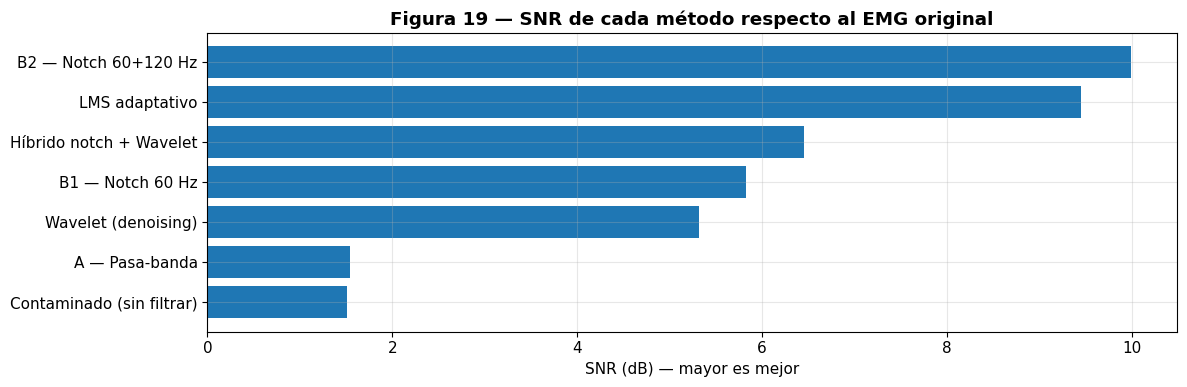

In [67]:
tabla_final = pd.DataFrame(resultados).T
tabla_final["Mejora SNR vs contaminado (dB)"] = tabla_final["SNR (dB)"] - tabla_final.loc["Contaminado (sin filtrar)", "SNR (dB)"]
display(tabla_final.round(4).sort_values("SNR (dB)", ascending=False))

# Gráfico de barras de SNR
plt.figure(figsize=(12, 4))
orden = tabla_final.sort_values("SNR (dB)")
plt.barh(orden.index, orden["SNR (dB)"], color="tab:blue")
plt.xlabel("SNR (dB) — mayor es mejor")
plt.title("Figura 19 — SNR de cada método respecto al EMG original")
plt.tight_layout(); plt.show()

### Comparación cualitativa (resultados del registro 01, bíceps braquial)

| Criterio | Pasa-banda 20–450 Hz | Notch 60+120 Hz | LMS adaptativo | Wavelet | Híbrido |
|---|---|---|---|---|---|
| Reducción de interferencias | Nula (60 y 120 Hz están dentro de la banda) | Alta | Alta (tras ≈ 0.5 s de convergencia) | Baja (sobreviven en D3–D4) | Alta (la aporta el notch) |
| Reducción de ruido gaussiano | Baja (solo fuera de 20–450 Hz) | Nula | Nula | Media, pero recorta también el EMG | Media |
| Conservación de la morfología | Alta | Alta | Alta | Baja (EMG débil anulado) | Media |
| Distorsión introducida | Mínima | Mínima (mayor con Q bajo) | Pequeña (ruido de adaptación; crece con μ) | Alta (encogimiento *soft*) | Media |
| **SNR / r obtenidos** | 1.5 dB / 0.76 | **10.0 dB / 0.95** | 9.5 dB / 0.95 | 5.3 dB / 0.84 | 6.5 dB / 0.91 |
| Complejidad | Baja | Baja | Media | Media | Media |
| ¿Qué necesita conocer? | Banda del EMG | Frecuencia exacta | Señal de referencia | Wavelet, niveles, umbral | Ambos |

> ⚖️ **Ningún método es universalmente superior.** La elección depende del tipo de contaminación, de qué información fisiológica debe conservarse y de la aplicación (monitoreo, diagnóstico, detección de contracciones, tiempo real…).

---
# 🟦 BLOQUE 6B — Extensión: las 10 señales EMG (4 músculos × 3 fases)

Hasta aquí analizamos **un** registro en detalle. En el tercer laboratorio obtuvimos 10 señales en total, por lo que ahora aplicamos exactamente el mismo procedimiento (contaminación del Bloque 3 → pasa-banda, notch, LMS, Wavelet e híbrido de los Bloques 4 y 5) a los 10 registros, y comparamos músculos y fases.

> Para cada registro se usan los mismos factores de contaminación que en el Bloque 3 (interferencia 1 = 1.0·σ a 60 Hz, interferencia 2 = 0.6·σ a 120 Hz, ruido = 0.3·σ, con σ = desviación estándar del propio registro). Así la contaminación es proporcional a cada señal y las SNR son comparables.

**Indicadores del EMG** (análisis de la señal original):

| Indicador | Qué mide |
|---|---|
| **RMS (mV)** | Amplitud efectiva: crece con la fuerza de la contracción. |
| **MNF / MDF (Hz)** | Frecuencia media / mediana del espectro (20 – 450 Hz): resumen del contenido en frecuencia. |
| **Saturación (%)** | Porcentaje de muestras recortadas por el conversor (0 o 1023). |

In [68]:
# ---------- Funciones auxiliares ----------
REL_1, REL_2, REL_RUIDO = 1.0, 0.6, 0.3     # mismos factores del Bloque 3 (relativos a σ de cada registro)

def cargar_registro(ruta):
    """Lee un archivo OpenSignals y devuelve (EMG en mV centrado, Fs, saturación %)."""
    meta = {}
    with open(ruta, "r", encoding="utf-8", errors="ignore") as f:
        for linea in f:
            if not linea.startswith("#"):
                break
            c = linea.lstrip("#").strip()
            if c.startswith("{"):
                meta = list(json.loads(c).values())[0]
    fs = int(meta.get("sampling rate", 1000))
    cols = meta.get("column")
    canal = meta.get("label", ["A1"])[0]
    res = meta.get("resolution", [])
    nbits = res[cols.index(canal)] if len(res) == len(cols) else 10
    adc = pd.read_csv(ruta, sep=r"\s+", comment="#", header=None).iloc[:, cols.index(canal)].to_numpy(float)
    mv = ((adc / 2**nbits) - 0.5) * VCC / G_EMG * 1000
    sat = np.mean((adc <= 0) | (adc >= 2**nbits - 1)) * 100
    return mv - np.mean(mv), fs, sat

def indicadores_espectrales(x, fs):
    """Frecuencia media (MNF) y mediana (MDF) del espectro de potencia entre 20 y 450 Hz."""
    f, p = signal.welch(x, fs, nperseg=2048)
    m = (f >= 20) & (f <= 450)
    f, p = f[m], p[m]
    mnf = np.sum(f * p) / np.sum(p)
    mdf = f[np.searchsorted(np.cumsum(p) / np.sum(p), 0.5)]
    return mnf, mdf

def metricas(ref, est, mascara):
    x, y = ref[mascara], est[mascara]
    error = y - x
    return {"SNR": 10 * np.log10(np.sum(x ** 2) / np.sum(error ** 2)), "r": np.corrcoef(x, y)[0, 1]}

def procesar_registro(x, fs, semilla):
    """Contamina y filtra un registro con los mismos métodos de los Bloques 3-5."""
    tt = np.arange(len(x)) / fs
    sd = np.std(x)
    r_local = np.random.default_rng(semilla)
    fa, fb = r_local.uniform(0, 2 * np.pi, size=2)
    cont = (x + REL_1 * sd * np.sin(2 * np.pi * f1 * tt + fa)
              + REL_2 * sd * np.sin(2 * np.pi * f2 * tt + fb)
              + r_local.normal(0, REL_RUIDO * sd, size=len(x)))
    refs = np.column_stack([np.sin(2 * np.pi * f1 * tt), np.cos(2 * np.pi * f1 * tt),
                            np.sin(2 * np.pi * f2 * tt), np.cos(2 * np.pi * f2 * tt)])
    notch = signal.filtfilt(b_notch2, a_notch2, signal.filtfilt(b_notch1, a_notch1, cont))
    sal = {
        "Pasa-banda": signal.sosfiltfilt(sos_pasabanda, cont),
        "Notch 60+120": notch,
        "LMS": filtro_lms(cont, refs, MU)[0],
        "Wavelet": denoising_wavelet(cont)[0],
        "Híbrido notch+Wavelet": denoising_wavelet(notch)[0],
    }
    mask = (tt >= MARGEN_S) & (tt <= tt[-1] - MARGEN_S)
    met = {"Contaminado": metricas(x, cont, mask)}
    met.update({k: metricas(x, v, mask) for k, v in sal.items()})
    return cont, sal, met

# ---------- Bucle sobre los 10 registros ----------
registros, filas = {}, []
for n, ruta in archivos.items():
    x, fs_n, sat = cargar_registro(ruta)
    cont, sal, met = procesar_registro(x, fs_n, semilla=100 + n)
    mnf, mdf = indicadores_espectrales(x, fs_n)
    registros[n] = {"x": x, "fs": fs_n, "cont": cont, "sal": sal}
    snr = {k: v["SNR"] for k, v in met.items()}
    mejor = max(sal, key=lambda k: snr[k])
    filas.append({
        "Archivo": n, "Músculo": MAPA[n][0], "Fase": MAPA[n][1],
        "Duración (s)": len(x) / fs_n, "RMS (mV)": np.std(x), "Saturación (%)": sat,
        "MNF (Hz)": mnf, "MDF (Hz)": mdf,
        **{f"SNR {k} (dB)": v for k, v in snr.items()},
        "Mejor método": mejor, "r del mejor": met[mejor]["r"],
    })

tabla_10 = pd.DataFrame(filas).set_index("Archivo").sort_index()
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 30)
display(tabla_10.round(2))

,Músculo,Fase,Duración (s),RMS (mV),Saturación (%),MNF (Hz),MDF (Hz),SNR Contaminado (dB),SNR Pasa-banda (dB),SNR Notch 60+120 (dB),SNR LMS (dB),SNR Wavelet (dB),SNR Híbrido notch+Wavelet (dB),Mejor método,r del mejor
Archivo,,,,,,,,,,,,,,,
1,Bíceps braquial,Sesión única,51.00,0.19,0.12,72.92,62.99,1.49,1.52,9.98,9.44,5.29,6.38,Notch 60+120,0.95
2,Abductor corto del pulgar,Reposo,30.60,0.01,0.00,108.75,60.06,1.01,0.83,3.36,3.26,1.42,0.80,Notch 60+120,0.74
3,Abductor corto del pulgar,Leve,41.10,0.17,0.04,143.12,129.39,1.38,1.43,9.63,9.54,3.25,3.15,Notch 60+120,0.95
4,Abductor corto del pulgar,Fuerza máxima,58.05,0.30,0.10,132.76,119.14,1.23,1.29,9.31,9.18,2.85,2.76,Notch 60+120,0.94
5,Trapecio superior,Reposo,31.65,0.04,0.00,56.21,48.34,1.08,1.06,9.38,8.82,3.50,4.15,Notch 60+120,0.94
6,Trapecio superior,Leve,43.05,0.16,0.00,60.33,53.22,0.36,0.34,8.91,8.39,3.87,5.01,Notch 60+120,0.94
7,Trapecio superior,Fuerza máxima,44.10,0.21,0.01,58.66,52.73,1.25,1.19,9.63,9.00,4.36,5.62,Notch 60+120,0.95
8,Cigomático mayor,Reposo,19.05,0.01,0.00,158.45,129.88,-2.15,-2.21,6.94,6.73,0.47,0.07,Notch 60+120,0.91
9,Cigomático mayor,Leve,27.90,0.02,0.00,134.93,111.82,1.29,1.27,9.64,9.37,1.33,0.88,Notch 60+120,0.95


,Músculo,Fase,Duración (s),RMS (mV),MNF (Hz),MDF (Hz)
0,Bíceps braquial,Reposo,19.00,0.034,74.032,60.059
1,Bíceps braquial,Leve,15.50,0.151,70.565,59.082
2,Bíceps braquial,Fuerza máxima,10.00,0.388,73.733,64.941
3,Abductor corto del pulgar,Reposo,30.60,0.007,108.748,60.059
4,Abductor corto del pulgar,Leve,41.10,0.166,143.118,129.395
5,Abductor corto del pulgar,Fuerza máxima,58.05,0.303,132.761,119.141
6,Trapecio superior,Reposo,31.65,0.041,56.213,48.340
7,Trapecio superior,Leve,43.05,0.156,60.331,53.223
8,Trapecio superior,Fuerza máxima,44.10,0.210,58.659,52.734
9,Cigomático mayor,Reposo,19.05,0.010,158.448,129.883


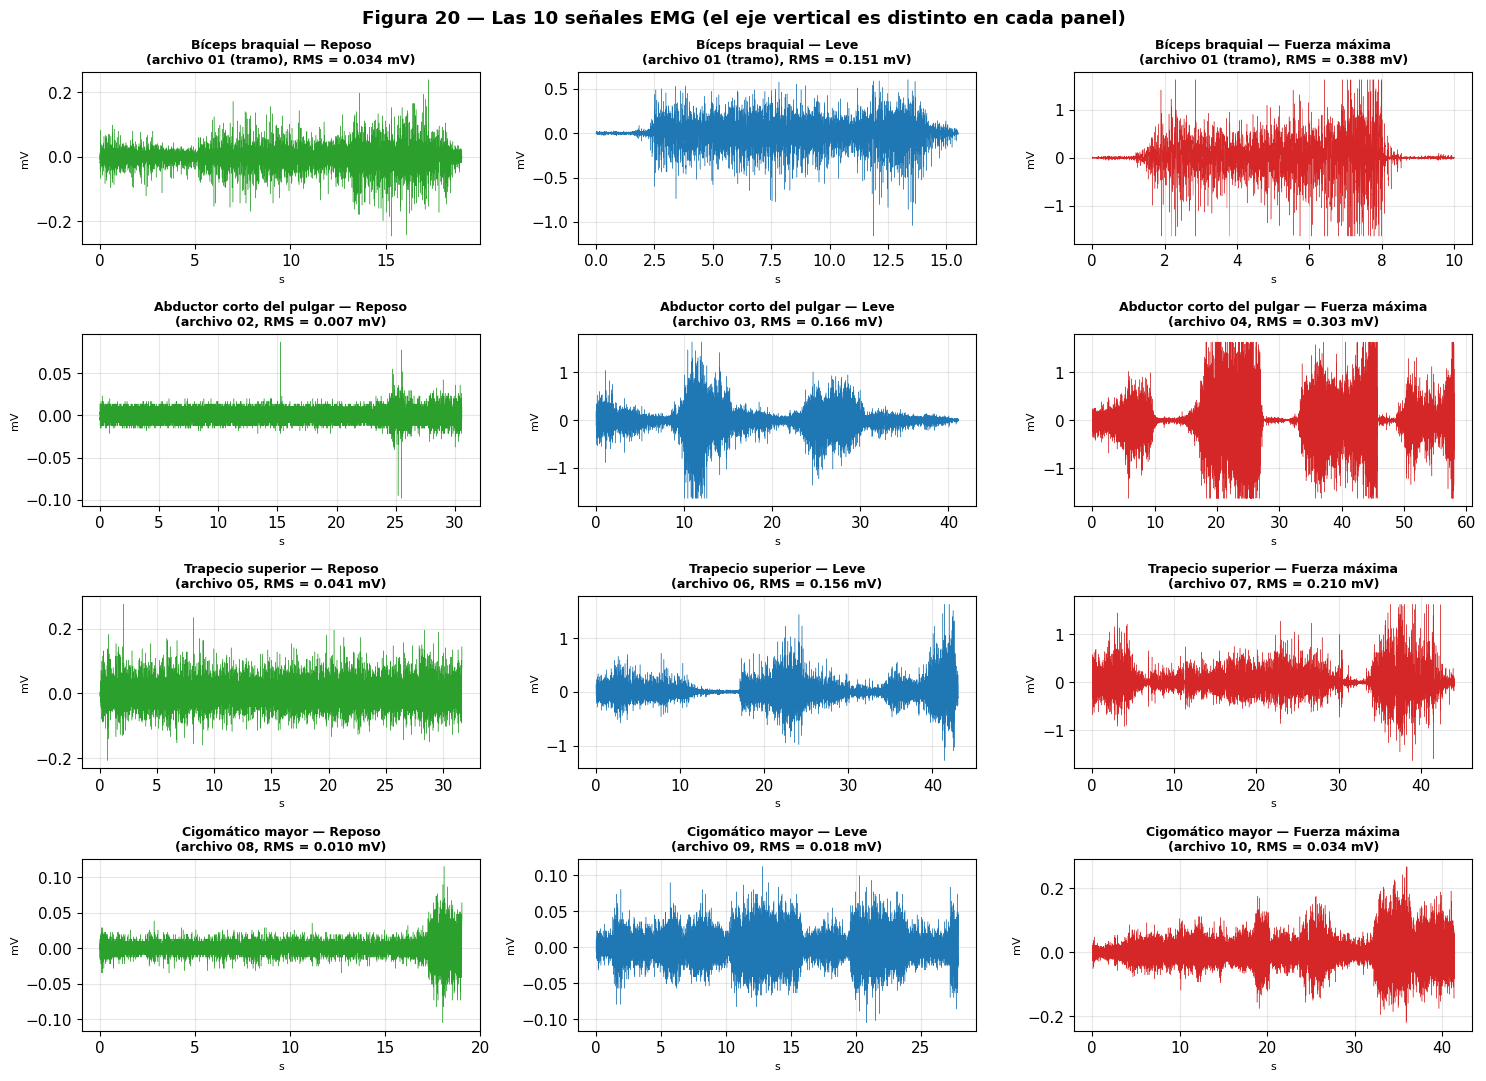

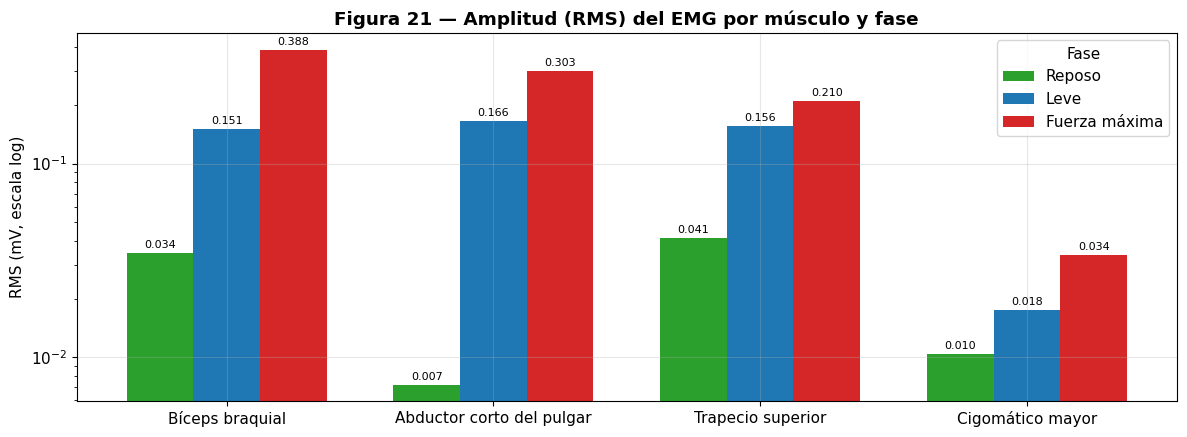

In [74]:
# ---------- Indicadores por músculo y fase (el bíceps se separa en sus 3 episodios) ----------
filas_fase = []
orden_musculos = ["Bíceps braquial", "Abductor corto del pulgar", "Trapecio superior", "Cigomático mayor"]
for n in sorted(archivos):
    x, fs_n = registros[n]["x"], registros[n]["fs"]
    if n == 1:
        tt = np.arange(len(x)) / fs_n
        for nombre, (a, b) in FASES_ARCHIVO_1.items():
            seg = x[(tt >= a) & (tt < b)]
            mnf, mdf = indicadores_espectrales(seg, fs_n)
            filas_fase.append({"Músculo": "Bíceps braquial", "Fase": nombre.split(" (")[0], "Duración (s)": len(seg) / fs_n,
                               "RMS (mV)": np.sqrt(np.mean(seg ** 2)), "MNF (Hz)": mnf, "MDF (Hz)": mdf})
    else:
        mnf, mdf = indicadores_espectrales(x, fs_n)
        filas_fase.append({"Músculo": MAPA[n][0], "Fase": MAPA[n][1], "Duración (s)": len(x) / fs_n,
                           "RMS (mV)": np.sqrt(np.mean(x ** 2)), "MNF (Hz)": mnf, "MDF (Hz)": mdf})
tabla_fases = pd.DataFrame(filas_fase)
tabla_fases["Fase"] = tabla_fases["Fase"].replace({"Contracción leve": "Leve"})
display(tabla_fases.round(3))

# ---------- Figura 20: las 10 señales (4 músculos × 3 fases) ----------
fases_orden = ["Reposo", "Leve", "Fuerza máxima"]
fig, ejes = plt.subplots(4, 3, figsize=(15, 11))
for i, mus in enumerate(orden_musculos):
    for j, fa_ in enumerate(fases_orden):
        eje = ejes[i, j]
        if mus == "Bíceps braquial":
            x, fs_n = registros[1]["x"], registros[1]["fs"]
            nombre = [k for k in FASES_ARCHIVO_1 if k.startswith(("Reposo", "Contracción leve", "Fuerza")[j])][0]
            a, b = FASES_ARCHIVO_1[nombre]
            x = x[int(a * fs_n):int(b * fs_n)]
            origen = "archivo 01 (tramo)"
        else:
            n = [k for k, v in MAPA.items() if v == (mus, fa_)][0]
            x, fs_n = registros[n]["x"], registros[n]["fs"]
            origen = f"archivo {n:02d}"
        eje.plot(np.arange(len(x)) / fs_n, x, lw=0.3, color=["tab:green", "tab:blue", "tab:red"][j])
        eje.set_title(f"{mus} — {fa_}\n({origen}, RMS = {np.sqrt(np.mean(x**2)):.3f} mV)", fontsize=9)
        eje.set_xlabel("s", fontsize=8); eje.set_ylabel("mV", fontsize=8)
fig.suptitle("Figura 20 — Las 10 señales EMG (el eje vertical es distinto en cada panel)", fontweight="bold")
plt.tight_layout(); plt.show()

# ---------- Figura 21: RMS por músculo y fase ----------
piv = tabla_fases.pivot(index="Músculo", columns="Fase", values="RMS (mV)").loc[orden_musculos, fases_orden]
ancho = 0.25
fig, eje = plt.subplots(figsize=(12, 4.5))
for k, (fa_, col) in enumerate(zip(fases_orden, ["tab:green", "tab:blue", "tab:red"])):
    barras = eje.bar(np.arange(4) + (k - 1) * ancho, piv[fa_], ancho, label=fa_, color=col)
    eje.bar_label(barras, fmt="%.3f", fontsize=8, padding=2)
eje.set_xticks(np.arange(4)); eje.set_xticklabels(orden_musculos)
eje.set_yscale("log"); eje.set_ylabel("RMS (mV, escala log)"); eje.legend(title="Fase")
eje.set_title("Figura 21 — Amplitud (RMS) del EMG por músculo y fase")
plt.tight_layout(); plt.show()

In [71]:
# ---------- Resumen global ----------
metodos = ["Contaminado", "Pasa-banda", "Notch 60+120", "LMS", "Wavelet", "Híbrido notch+Wavelet"]
resumen = pd.DataFrame({
    "SNR promedio (dB)": [tabla_10[f"SNR {m} (dB)"].mean() for m in metodos],
    "SNR mínima (dB)": [tabla_10[f"SNR {m} (dB)"].min() for m in metodos],
    "SNR máxima (dB)": [tabla_10[f"SNR {m} (dB)"].max() for m in metodos],
}, index=metodos)
resumen["Mejora vs contaminado (dB)"] = resumen["SNR promedio (dB)"] - resumen.loc["Contaminado", "SNR promedio (dB)"]
display(resumen.round(2))
print("Método con mejor SNR (nº de registros ganados):")
print(tabla_10["Mejor método"].value_counts().to_string())

,SNR promedio (dB),SNR mínima (dB),SNR máxima (dB),Mejora vs contaminado (dB)
Contaminado,0.81,-2.15,1.49,0.00
Pasa-banda,0.79,-2.21,1.52,-0.02
Notch 60+120,8.62,3.36,9.98,7.81
LMS,8.30,3.26,9.54,7.49
Wavelet,2.84,0.47,5.29,2.03
Híbrido notch+Wavelet,3.05,0.07,6.38,2.24


Método con mejor SNR (nº de registros ganados):
Mejor método
Notch 60+120    10


### 🔎 Interpretación — 10 señales

- **Amplitud:** en los cuatro músculos la RMS crece con la fuerza (reposo < leve < máxima): pulgar 0.007 → 0.166 → 0.303 mV; trapecio 0.041 → 0.156 → 0.210 mV; cigomático 0.010 → 0.018 → 0.034 mV; bíceps (tramos del archivo 01) 0.034 → 0.151 → 0.388 mV. El cigomático (músculo facial pequeño) tiene amplitudes mucho menores que el bíceps o el pulgar. Esta progresión confirma el orden de las fases.
- **Frecuencia:** el trapecio tiene las frecuencias más bajas (MNF ≈ 56 – 60 Hz, MDF ≈ 48 – 53 Hz) y el pulgar y el cigomático las más altas (MNF ≈ 110 – 160 Hz); el bíceps queda en ≈ 71 – 74 Hz. No se ve una tendencia clara con la fuerza. En reposo estos valores se deben tomar con cuidado: la señal es tan pequeña que domina el ruido y el zumbido de 60 Hz (en el pulgar en reposo la MDF es 60 Hz).
- **Filtrado:** el notch fue el mejor método en los 10 registros (SNR promedio 8.6 dB, entre 3.3 y 10.0 dB) y el LMS quedó muy cerca (8.3 dB). El híbrido (3.1 dB) y la Wavelet (2.9 dB) mejoraron poco, y el pasa-banda no mejoró nada (0.8 dB frente a 0.8 dB de la señal contaminada).
- **Casos bajos:** los registros de reposo tienen el SNR más bajo (por ejemplo, el notch da 3.4 dB en el archivo 02). En el 02 el "original" ya contiene un zumbido de 60 Hz real que los filtros eliminan y que se cuenta como error. En el 08 el SNR contaminado es negativo (−2.2 dB) porque la única contracción está al final y cae en los 2 s de margen que se excluyen de la métrica.
- **Saturación:** solo 01, 03 y 04 (fuerza máxima o contracción fuerte) saturan el conversor, y apenas entre 0.04 % y 0.12 % de las muestras.

---
# 🟦 BLOQUE 7 — Retroalimentación, síntesis e infografía *(15 min)*

## 📝 Actividad de análisis

Responde de forma breve y justificada (2 – 4 líneas por pregunta).

**Pregunta 1.** ¿Por qué es importante conocer la frecuencia de muestreo de una señal biomédica?

✍️ **Respuesta:**

Determina el **eje de tiempo** ($t = n/F_s$), la **frecuencia máxima observable** (Nyquist = $F_s/2$ = 500 Hz aquí) y el diseño de los filtros, cuyas frecuencias de corte se definen respecto a $F_s$. Con 1000 Hz se cubre todo el EMG de superficie (20 – 450 Hz) sin aliasing.

**Pregunta 2.** ¿Qué diferencia existe entre ruido e interferencia?

✍️ **Respuesta:**

El **ruido** es aleatorio y de banda ancha (ruido gaussiano, ruido electrónico). La **interferencia** tiene una fuente identificable y una estructura definida, por ejemplo la red eléctrica a 60 Hz (y sus armónicos).

**Pregunta 3.** ¿Por qué una interferencia sinusoidal puede observarse como un pico en el dominio de la frecuencia?

✍️ **Respuesta:**

Porque una sinusoide tiene toda su energía en **una sola frecuencia**. La FFT mide cuánto hay de cada frecuencia, así que esa energía aparece concentrada en un pico estrecho en $f_0$.

**Pregunta 4.** ¿Qué sucede cuando aplicamos un filtro demasiado agresivo a una señal EMG? *x*

✍️ **Respuesta:**

Se pierde señal útil y se distorsiona el resultado. Por ejemplo, con `fc_baja = 150` el pasa-banda elimina casi todo el EMG (su energía está entre 20 y 250 Hz): sobre el EMG original da un SNR de 0.4 dB y r = 0.29, es decir, la señal deja de parecerse a la original. Con un notch de Q muy bajo pasa algo parecido (Q = 5 baja el SNR a 6.7 dB).

**Pregunta 5.** ¿Cuál es la principal diferencia conceptual entre un filtro convencional y un filtro adaptativo?

✍️ **Respuesta:**

El filtro convencional tiene **coeficientes fijos**, diseñados una vez y aplicados igual a toda la señal. El adaptativo **ajusta sus coeficientes muestra a muestra** (aquí con LMS) usando una señal de referencia y el error, por lo que puede seguir interferencias que cambian de amplitud o fase.

**Pregunta 6.** ¿Para qué sirve la Transformada Wavelet?

✍️ **Respuesta:**

Descompone una señal en **escalas (frecuencias) y en el tiempo** a la vez, mediante wavelets de duración limitada. Sirve para ver qué frecuencias hay y cuándo aparecen, para eliminar ruido (*denoising* por umbralización), detectar eventos y comprimir señales.

**Pregunta 7.** ¿Por qué la Transformada Wavelet puede resultar útil para analizar señales biomédicas?

✍️ **Respuesta:**

Porque las señales biomédicas suelen ser **no estacionarias**: sus características cambian en el tiempo. El EMG, por ejemplo, cambia de amplitud y contenido frecuencial entre reposo, contracción leve y fuerza máxima. La Wavelet localiza esos cambios en el tiempo, algo que la FFT global no puede hacer.

**Pregunta 8.** ¿Qué información podría perderse durante el proceso de filtrado?

✍️ **Respuesta:**

Se pueden perder: el EMG por debajo de 20 Hz y por encima de 450 Hz; la banda estrecha alrededor de 60 y 120 Hz (que también contiene EMG); y, con la Wavelet, el EMG débil (se anuló el 100 % de los coeficientes de D7 y D8) y parte de la amplitud (con *soft* la RMS de la fuerza máxima baja de 0.388 a 0.312 mV).

**Pregunta 9.** Si conoces la frecuencia exacta de una interferencia, ¿qué tipo de filtro podrías utilizar?

✍️ **Respuesta:**

Un **filtro notch** centrado en esa frecuencia (con Q alto si se conoce con precisión), o un **filtro adaptativo** que use una referencia sinusoidal de esa frecuencia.

**Pregunta 10.** ¿Por qué no debemos evaluar un filtro únicamente observando visualmente la señal?

✍️ **Respuesta:**

Porque la vista engaña y una buena apariencia no garantiza fidelidad. Por ejemplo, el pasa-banda parece conservar la forma de la señal pero su SNR es de solo 1.5 dB, y la Wavelet se ve "limpia" pero pierde EMG (SNR 5.3 dB). Además, el SNR global puede ocultar diferencias entre tramos: con el notch es de 14.3 dB en fuerza máxima y de −4.4 dB en reposo. Hay que combinar la inspección visual con métricas (SNR, r, RMSE).

## 🧠 SUMARIZE — ¿Qué aprendimos?

Resume en pocas líneas:

```text
1. ¿Qué problema tenía la señal?
2. ¿Cómo contaminamos la señal?
3. ¿Qué filtro utilizamos?
4. ¿Qué resultado obtuvimos?
5. ¿Para qué sirve un filtro adaptativo?
6. ¿Para qué sirve Wavelet?
7. ¿Qué método utilizarías y por qué?
```

✍️ **Respuesta:**

1. El EMG real (bíceps braquial, BITalino, Fs = 1000 Hz, 51 s) es una señal aleatoria de banda ancha (20 – 450 Hz) y solo trae un poco de ruido propio; el problema fue recuperarlo cuando se contamina con interferencia de la red y ruido.
2. Se sumó una interferencia de **60 Hz** (amplitud 1.0·σ = 0.192 mV), otra de **120 Hz** (0.6·σ = 0.115 mV) y **ruido gaussiano** (σ = 0.3·σ_señal = 0.058 mV). El SNR bajó a 1.5 dB.
3. Pasa-banda Butterworth 20 – 450 Hz (orden 4); notch a 60 y 120 Hz (Q = 30); filtro adaptativo LMS (μ = 0.005, referencias seno/coseno de 60 y 120 Hz); Wavelet db4 de 8 niveles con umbral universal *soft* (0.299 mV); e híbrido notch + Wavelet.
4. En el registro 01: notch 10.0 dB (r = 0.95), LMS 9.5 dB (0.95), híbrido 6.5 dB (0.91), Wavelet 5.3 dB (0.84), pasa-banda 1.5 dB (0.76). En los 10 registros el notch fue el mejor siempre (mejora media de +7.8 dB), el LMS lo siguió de cerca (+7.5 dB), y la Wavelet y el híbrido mejoraron solo ≈ 2 dB.
5. Para cancelar una interferencia cuyos parámetros cambian o no se conocen con exactitud: el filtro ajusta sus coeficientes con una señal de referencia y el error, estima la interferencia y la resta.
6. Para analizar y filtrar señales no estacionarias en tiempo y escala: ver cuándo aparece cada banda de frecuencias y eliminar ruido umbralizando coeficientes.
7. Un **notch** (o el **LMS** si la frecuencia de la red varía), precedido del pasa-banda 20 – 450 Hz. Recuperan mejor la señal con muy poca distorsión; la Wavelet con umbral universal no es adecuada para EMG porque el propio EMG es de banda ancha y se recorta.

## 🎨 Actividad final — Infografía científica

Elabora una infografía sencilla (Canva, PowerPoint, Google Slides o a mano y fotografiada) con estas secciones:

1. **Señal original** — EMG adquirido con BITalino/OpenSignals (Fs, duración, canal A1).
2. **Contaminación** — `EMG + interferencia 1 + interferencia 2 + ruido` (indica frecuencias y amplitudes usadas).
3. **Filtrado** — método(s) aplicado(s) y sus parámetros.
4. **Resultado** — comparación *Original / Contaminada / Filtrada* + una métrica (SNR o r).
5. **Conceptos clave** — una línea para cada uno: *Ruido, Interferencia, Filtro, Filtro adaptativo, Wavelet, Denoising*.
6. **Conclusión** — 3 a 5 líneas: ¿qué método recuperó mejor la señal y qué limitaciones observaste?

**Flujo que debe mostrar la infografía:**

```text
EMG REAL → CONTAMINACIÓN → ANÁLISIS → FILTRADO → FILTRO ADAPTATIVO → WAVELET → COMPARACIÓN → CONCLUSIONES
```

La siguiente celda genera una **figura base** con tus propios resultados que puedes insertar en la infografía.

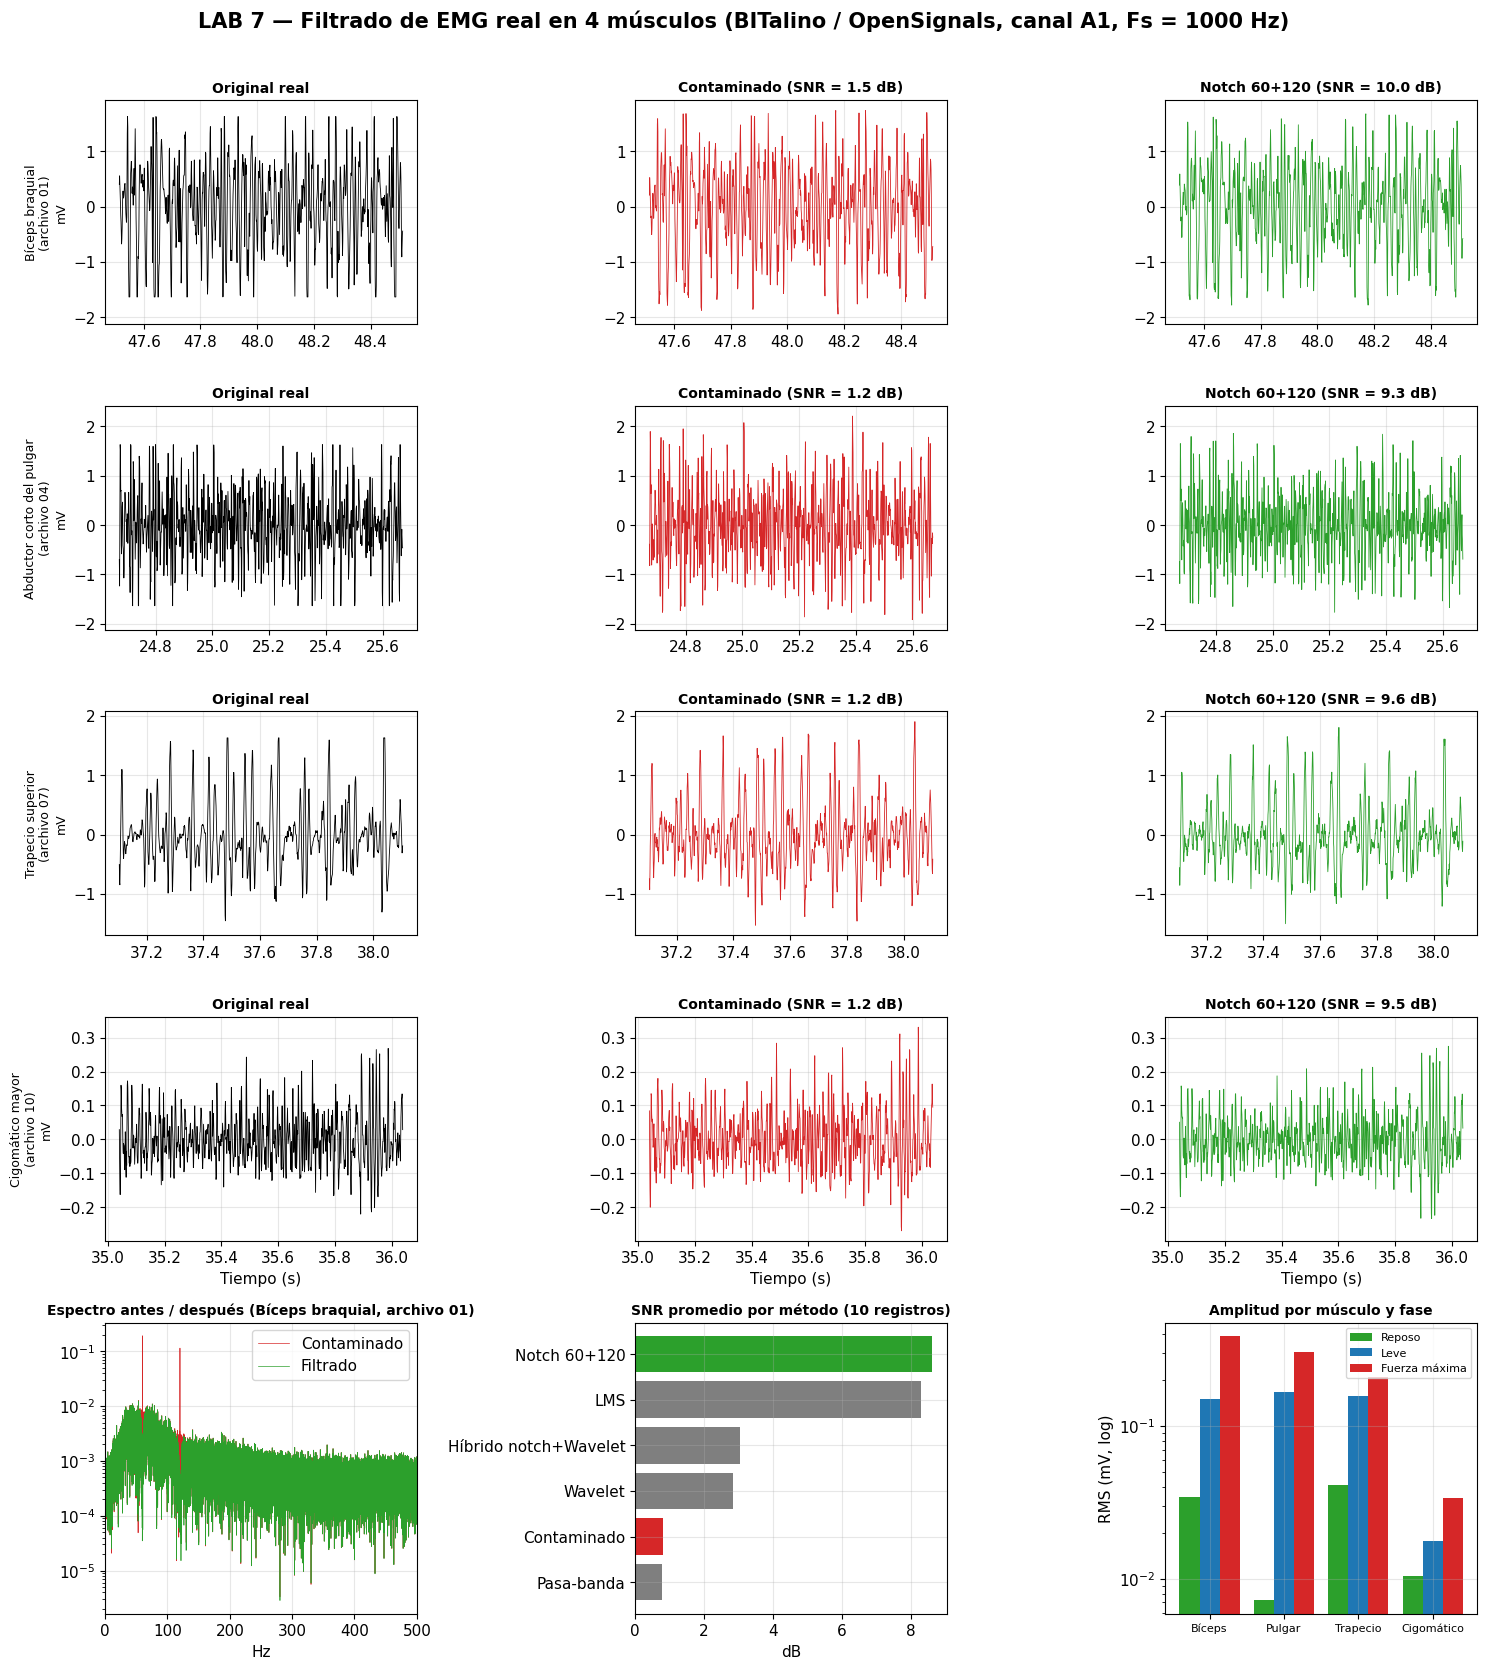

Figura guardada como 'figura_base_infografia.png'


In [72]:
# Elige el método para la infografía. Claves: "Pasa-banda", "Notch 60+120", "LMS", "Wavelet", "Híbrido notch+Wavelet"
METODO_ELEGIDO = "Notch 60+120"
VENTANA_S = 1.0                                   # ancho de la ventana que se muestra en cada fila (s)
fases_orden = ["Reposo", "Leve", "Fuerza máxima"]
orden_musculos = ["Bíceps braquial", "Abductor corto del pulgar", "Trapecio superior", "Cigomático mayor"]

def registro_de(musculo, fase):
    """Número de archivo de un músculo y fase (el bíceps está entero en el archivo 1)."""
    if musculo == "Bíceps braquial":
        return 1
    return [k for k, v in MAPA.items() if v == (musculo, fase)][0]

def ventana_mas_activa(x, fs, a=0, b=None, dur=VENTANA_S):
    """Índices (i, j) de la ventana de 'dur' s con más energía entre los segundos a y b."""
    i0 = int(a * fs)
    i1 = int((b if b is not None else len(x) / fs) * fs)
    w = int(dur * fs)
    e = np.cumsum(np.insert(x[i0:i1] ** 2, 0, 0))
    ini = i0 + int(np.argmax(e[w:] - e[:-w]))
    return ini, ini + w

fig = plt.figure(figsize=(15, 17))
grid = fig.add_gridspec(5, 3, height_ratios=[1, 1, 1, 1, 1.3])

# ---------- Filas 1-4: un músculo por fila (fuerza máxima): original | contaminado | filtrado ----------
for i, mus in enumerate(orden_musculos):
    n = registro_de(mus, "Fuerza máxima")
    r = registros[n]
    fs_n = r["fs"]
    if mus == "Bíceps braquial":
        a, b = FASES_ARCHIVO_1["Fuerza máxima"]
    else:
        a, b = 0, None
    i0, i1 = ventana_mas_activa(r["x"], fs_n, a, b)
    tt = np.arange(i0, i1) / fs_n

    snr_c = tabla_10.loc[n, "SNR Contaminado (dB)"]
    snr_f = tabla_10.loc[n, f"SNR {METODO_ELEGIDO} (dB)"]
    paneles = [
        ("Original real", r["x"], "black"),
        (f"Contaminado (SNR = {snr_c:.1f} dB)", r["cont"], "tab:red"),
        (f"{METODO_ELEGIDO} (SNR = {snr_f:.1f} dB)", r["sal"][METODO_ELEGIDO], "tab:green"),
    ]
    eje0 = None
    for j, (titulo, senal, color) in enumerate(paneles):
        eje = fig.add_subplot(grid[i, j], sharey=eje0)
        if j == 0:
            eje0 = eje
            eje.set_ylabel(f"{mus}\n(archivo {n:02d})\nmV", fontsize=9)
        eje.plot(tt, senal[i0:i1], color=color, lw=0.6)
        eje.set_title(titulo, fontsize=10)
        if i == len(orden_musculos) - 1:
            eje.set_xlabel("Tiempo (s)")

# ---------- Fila 5: resumen ----------
# (a) Espectro antes / después del registro principal
n0 = ARCHIVO_PRINCIPAL
ax_e = fig.add_subplot(grid[4, 0])
fr_c, am_c = espectro_amplitud(registros[n0]["cont"], registros[n0]["fs"])
fr_f, am_f = espectro_amplitud(registros[n0]["sal"][METODO_ELEGIDO], registros[n0]["fs"])
ax_e.semilogy(fr_c, am_c, color="tab:red", lw=0.5, label="Contaminado")
ax_e.semilogy(fr_f, am_f, color="tab:green", lw=0.5, label="Filtrado")
ax_e.set_xlim(0, F_MAX_GRAFICO); ax_e.legend(); ax_e.set_xlabel("Hz")
ax_e.set_title(f"Espectro antes / después ({MAPA[n0][0]}, archivo {n0:02d})", fontsize=10)

# (b) SNR promedio por método sobre los 10 registros
ax_s = fig.add_subplot(grid[4, 1])
nombres = ["Contaminado"] + list(registros[n0]["sal"].keys())
snr_prom = pd.Series({k: tabla_10[f"SNR {k} (dB)"].mean() for k in nombres}).sort_values()
cols = ["tab:green" if k == METODO_ELEGIDO else ("tab:red" if k == "Contaminado" else "tab:gray") for k in snr_prom.index]
ax_s.barh(snr_prom.index, snr_prom.values, color=cols)
ax_s.set_xlabel("dB")
ax_s.set_title("SNR promedio por método (10 registros)", fontsize=10)

# (c) RMS por músculo y fase
ax_r = fig.add_subplot(grid[4, 2])
piv = tabla_fases.pivot(index="Músculo", columns="Fase", values="RMS (mV)").loc[orden_musculos, fases_orden]
ancho = 0.27
for k, (fa_, col) in enumerate(zip(fases_orden, ["tab:green", "tab:blue", "tab:red"])):
    ax_r.bar(np.arange(4) + (k - 1) * ancho, piv[fa_], ancho, label=fa_, color=col)
ax_r.set_yscale("log"); ax_r.set_ylabel("RMS (mV, log)")
ax_r.set_xticks(np.arange(4)); ax_r.set_xticklabels(["Bíceps", "Pulgar", "Trapecio", "Cigomático"], fontsize=8)
ax_r.legend(fontsize=8)
ax_r.set_title("Amplitud por músculo y fase", fontsize=10)

fig.suptitle(f"LAB 7 — Filtrado de EMG real en 4 músculos (BITalino / OpenSignals, canal {CANAL}, Fs = {registros[n0]['fs']} Hz)",
             fontsize=15, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("figura_base_infografia.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada como 'figura_base_infografia.png'")

## 🔁 Guía de retroalimentación para el docente (últimos 30 min)

| Momento | Actividad |
|---|---|
| min 90 – 95 | Cierre de la discusión Wavelet: ¿por qué sobrevivieron las interferencias al umbral? |
| min 95 – 105 | Revisar la tabla final y la Figura 19: comparar filtros; contrastar métricas con lo visual. |
| min 105 – 112 | Discutir errores frecuentes y revisar respuestas a las preguntas 1 – 10. |
| min 112 – 120 | Revisar avance de la síntesis e infografía; responder preguntas. |

**Errores frecuentes a discutir:**
- Graficar `nSeq` o las columnas digitales como si fueran EMG.
- Usar `nSeq` como eje de tiempo.
- Confundir ruido (aleatorio, banda ancha) con interferencia (estructurada, banda estrecha).
- Elegir un pasa-bajas con corte muy bajo y "aplanar" la señal.
- Interpretar que una SNR alta garantiza una morfología clínicamente correcta.
- Olvidar que el LMS necesita un tiempo de convergencia.
- Asumir que la Wavelet elimina cualquier tipo de contaminación.

**Ideas clave para el cierre:**
- Filtro **convencional**: coeficientes fijos, efectivo si conocemos la banda del ruido.
- Filtro **adaptativo**: coeficientes que cambian, requiere una referencia, sigue interferencias variables.
- **Wavelet**: análisis tiempo-escala, útil para eventos localizados (contracciones) y ruido de banda ancha.
- En la práctica se **combinan** técnicas según el problema.

## ✅ Conclusiones del laboratorio

✍️ **Conclusiones:**

- **Mejor método:** con EMG, el **notch** (SNR 10.0 dB, r = 0.95 en el registro 01) y el **LMS** (9.5 dB, r = 0.95) recuperaron mejor la señal; el notch fue el mejor en los 10 registros (SNR promedio 8.6 dB frente a 0.8 dB de la señal contaminada). El pasa-banda casi no ayudó (+0 dB), porque en EMG la red de 60 y 120 Hz cae dentro de la banda útil (20 – 450 Hz), a diferencia del ECG.
- **Ruido gaussiano:** ningún método lo elimina bien. El EMG es de banda ancha, así que ruido y señal comparten frecuencias. El tope de SNR (≈ 10.5 dB con este nivel de ruido) lo marca justo ese ruido.
- **Wavelet:** con umbral universal *soft* eliminó EMG útil (se anuló el 100 % de D7–D8 y la RMS de la fuerza máxima bajó de 0.388 a 0.312 mV) y su SNR fue de solo 5.3 dB. El híbrido mejora si se usa umbral *hard* (9.4 dB).
- **LMS:** casi igual de bueno que el notch y más flexible (sigue interferencias variables), pero depende de μ: lento si es pequeño y ruidoso si es grande (3.9 dB con μ = 0.05), y necesita una señal de referencia.
- **Limitaciones:** (1) la señal "original" ya contiene ruido propio (en el reposo del pulgar, archivo 02, hay un pico de 60 Hz real); (2) el SNR global lo domina la contracción fuerte: en la fase de reposo el notch da ≈ −4 dB; (3) la contaminación es artificial y relativa a la desviación estándar de cada registro; (4) el registro 01 reúne las tres fases y la separación se hizo a partir de la envolvente.

---
# 📦 ENTREGA

### 1. Jupyter Notebook (`.ipynb`)
Debe contener:
- código ejecutado sin errores;
- todos los gráficos generados;
- respuestas a las preguntas de cada bloque y a las 10 preguntas de análisis;
- interpretación de resultados;
- sección *SUMARIZE* y conclusiones.

### 2. Infografía (PDF o PNG)
Debe sintetizar el flujo completo:

```text
EMG REAL
   ↓
CONTAMINACIÓN
   ↓
ANÁLISIS
   ↓
FILTRADO
   ↓
FILTRO ADAPTATIVO
   ↓
WAVELET
   ↓
COMPARACIÓN
   ↓
CONCLUSIONES
```

**Nombre de archivos sugerido:** `LAB7_Apellido_Nombre.ipynb` y `LAB7_Apellido_Nombre_infografia.pdf`

# 📊 Criterios de evaluación

| Criterio | Peso | Logrado (100%) | En proceso (50%) | No logrado (0%) |
|---|---:|---|---|---|
| Carga y comprensión de datos | 15% | Lee cabecera, identifica A1, construye `t` correctamente y justifica no usar `nSeq`. | Carga los datos con errores menores de interpretación. | No identifica el canal EMG o usa un eje temporal incorrecto. |
| Contaminación artificial | 15% | Genera y visualiza ambas interferencias y el ruido; interpreta el espectro. | Genera la contaminación pero la interpretación es incompleta. | No genera la contaminación o no la analiza. |
| Aplicación de filtros | 20% | Aplica pasa-banda y notch, muestra respuestas en frecuencia y explica efectos. | Aplica los filtros sin justificar parámetros. | No aplica los filtros correctamente. |
| Análisis e interpretación | 20% | Integra métricas y observación visual; reconoce distorsiones y limitaciones. | Interpretación superficial o solo visual. | Sin interpretación. |
| Filtro adaptativo y Wavelet | 15% | Explica el LMS (referencia, error, coeficientes) y el denoising Wavelet; experimenta con parámetros. | Ejecuta el código sin explicar los conceptos. | No aborda estos métodos. |
| Infografía y comunicación | 15% | Infografía clara, completa (6 secciones) y con conclusión fundamentada. | Infografía incompleta o poco clara. | No entrega infografía. |
| **Total** | **100%** | | | |